#### Imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """
    Search the current directory and its parents for the project root.

    The project root must contain both:
    - config/__init__.py
    - src/__init__.py
    """
    start_path = (start or Path.cwd()).resolve()

    for candidate in (start_path, *start_path.parents):
        config_init = candidate / "config" / "__init__.py"
        src_init = candidate / "src" / "__init__.py"

        if config_init.is_file() and src_init.is_file():
            return candidate

    raise FileNotFoundError(
        "Project root could not be found. "
        "Confirm that config/__init__.py and src/__init__.py exist."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Project root added to sys.path: {str(PROJECT_ROOT) in sys.path}")

Project root: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los
Project root added to sys.path: True


In [2]:
from config.paths import DEMO_DATA_DIR

PATIENT_FILE = DEMO_DATA_DIR / "patient.csv"
DIAGNOSIS_FILE = DEMO_DATA_DIR / "diagnosis.csv"
ADMISSION_DX_FILE = DEMO_DATA_DIR / "admissionDx.csv"

for file_path in (
    PATIENT_FILE,
    DIAGNOSIS_FILE,
    ADMISSION_DX_FILE,
):
    if not file_path.is_file():
        raise FileNotFoundError(
            f"Missing file: {file_path}"
        )

print("All required demo files were found.")

All required demo files were found.


In [ ]:
from src.database import get_engine

engine = get_engine()

print("Database engine initialized.")

#### Load the data

In [3]:
import pandas as pd

patient = pd.read_csv(
    PATIENT_FILE,
    low_memory=False,
)

diagnosis = pd.read_csv(
    DIAGNOSIS_FILE,
    low_memory=False,
)

admission_dx = pd.read_csv(
    ADMISSION_DX_FILE,
    low_memory=False,
)

print(f"patient: {patient.shape}")
print(f"diagnosis: {diagnosis.shape}")
print(f"admissionDx: {admission_dx.shape}")

patient: (2520, 29)
diagnosis: (24978, 7)
admissionDx: (7578, 6)


#### Basic information

In [4]:
for name, df in {
    "patient": patient,
    "diagnosis": diagnosis,
    "admissionDx": admission_dx,
}.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.head())

    display(df.info())

    display(df.describe(include="all"))

patient


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,ICU to SDU,2,stepdown/other,NaN,NaN,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,Emergency Department,1,admit,46.5,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          2520 non-null   int64  
 1   patienthealthsystemstayid  2520 non-null   int64  
 2   gender                     2516 non-null   object 
 3   age                        2516 non-null   object 
 4   ethnicity                  2481 non-null   object 
 5   hospitalid                 2520 non-null   int64  
 6   wardid                     2520 non-null   int64  
 7   apacheadmissiondx          2221 non-null   object 
 8   admissionheight            2451 non-null   float64
 9   hospitaladmittime24        2520 non-null   object 
 10  hospitaladmitoffset        2520 non-null   int64  
 11  hospitaladmitsource        1926 non-null   object 
 12  hospitaldischargeyear      2520 non-null   int64  
 13  hospitaldischargetime24    2520 non-null   objec

None

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
count,2.520000e+03,2.520000e+03,2516,2516,2481,2520.000000,2520.000000,2221,2451.000000,2520,...,2498,2520.000000,2520,2322.000000,1236.000000,2520,2520.000000,2516,2518,2520
unique,NaN,NaN,2,76,6,NaN,NaN,236,NaN,1339,...,13,NaN,4,NaN,NaN,978,NaN,15,2,1841
top,NaN,NaN,Male,> 89,Caucasian,NaN,NaN,"Sepsis, pulmonary",NaN,18:26:00,...,Emergency Department,NaN,admit,NaN,NaN,20:00:00,NaN,Floor,Alive,006-100497
freq,NaN,NaN,1508,98,2010,NaN,NaN,121,NaN,9,...,1304,NaN,2064,NaN,NaN,14,NaN,1188,2392,24
mean,1.666226e+06,1.326635e+06,NaN,NaN,NaN,261.042460,629.305952,NaN,169.740445,NaN,...,NaN,1.200000,NaN,83.087795,83.051586,NaN,3484.075000,NaN,NaN,NaN
std,1.022224e+06,8.311521e+05,NaN,NaN,NaN,119.109829,318.083552,NaN,15.986092,NaN,...,NaN,0.510003,NaN,26.606384,26.465304,NaN,4977.160994,NaN,NaN,NaN
min,1.417640e+05,1.293910e+05,NaN,NaN,NaN,56.000000,82.000000,NaN,0.300000,NaN,...,NaN,1.000000,NaN,0.500000,22.300000,NaN,0.000000,NaN,NaN,NaN
25%,7.722628e+05,5.938000e+05,NaN,NaN,NaN,158.000000,376.000000,NaN,162.600000,NaN,...,NaN,1.000000,NaN,65.500000,64.275000,NaN,1137.750000,NaN,NaN,NaN
50%,1.590372e+06,1.230992e+06,NaN,NaN,NaN,252.500000,626.000000,NaN,170.200000,NaN,...,NaN,1.000000,NaN,79.300000,79.550000,NaN,2120.000000,NaN,NaN,NaN
75%,2.697422e+06,2.165279e+06,NaN,NaN,NaN,384.500000,957.000000,NaN,177.800000,NaN,...,NaN,1.000000,NaN,96.600000,98.400000,NaN,3998.500000,NaN,NaN,NaN


...

admissionDx


,admissiondxid,patientunitstayid,admitdxenteredoffset,admitdxpath,admitdxname,admitdxtext
0,7351978,2900423,162,admission diagnosis|Non-operative Organ System...,Cardiovascular,Cardiovascular
1,7351977,2900423,162,admission diagnosis|Was the patient admitted f...,No,No
2,7351979,2900423,162,admission diagnosis|All Diagnosis|Non-operativ...,"Sepsis, pulmonary","Sepsis, pulmonary"
3,7745060,2902156,944,admission diagnosis|All Diagnosis|Non-operativ...,"Rhythm disturbance (atrial, supraventricular)","Rhythm disturbance (atrial, supraventricular)"
4,7745059,2902156,944,admission diagnosis|Non-operative Organ System...,Cardiovascular,Cardiovascular


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7578 entries, 0 to 7577
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   admissiondxid         7578 non-null   int64 
 1   patientunitstayid     7578 non-null   int64 
 2   admitdxenteredoffset  7578 non-null   int64 
 3   admitdxpath           7578 non-null   object
 4   admitdxname           7578 non-null   object
 5   admitdxtext           7578 non-null   object
dtypes: int64(3), object(3)
memory usage: 355.3+ KB


None

,admissiondxid,patientunitstayid,admitdxenteredoffset,admitdxpath,admitdxname,admitdxtext
count,7.578000e+03,7.578000e+03,7578.000000,7578,7578,7578
unique,NaN,NaN,NaN,294,268,280
top,NaN,NaN,NaN,admission diagnosis|Was the patient admitted f...,No,No
freq,NaN,NaN,NaN,1876,2077,2077
mean,5.050520e+06,1.759456e+06,116.404724,NaN,NaN,NaN
std,2.750455e+06,1.007059e+06,273.552377,NaN,NaN,NaN
min,4.713860e+05,1.417650e+05,-1940.000000,NaN,NaN,NaN
25%,2.515990e+06,9.316808e+05,12.000000,NaN,NaN,NaN
50%,5.013230e+06,1.716263e+06,36.000000,NaN,NaN,NaN
75%,7.882003e+06,2.735374e+06,97.000000,NaN,NaN,NaN


#### Missing values

In [5]:
def missing_values(df):

    return (
        df
        .isna()
        .sum()
        .to_frame("Missing")
        .assign(
            Percentage=lambda x:
            100 * x["Missing"] / len(df)
        )
        .sort_values(
            "Percentage",
            ascending=False
        )
    )

missing_values(patient)

,Missing,Percentage
dischargeweight,1284,50.952381
hospitaladmitsource,594,23.571429
apacheadmissiondx,299,11.865079
admissionweight,198,7.857143
admissionheight,69,2.738095
ethnicity,39,1.547619
hospitaldischargelocation,32,1.269841
hospitaldischargestatus,28,1.111111
unitadmitsource,22,0.873016
gender,4,0.158730


#### identifying potential lung cancer cases

In [6]:
cancer_keywords = [
    "lung",
    "pulmonary",
    "bronch",
    "carcinoma",
    "adenocarcinoma",
    "small cell",
    "non-small",
    "nsclc",
    "sclc",
    "malignan",
    "neoplasm",
    "tumor",
    "cancer",
    "metast",
]

In [7]:
mask = diagnosis["diagnosisstring"].str.contains(
    "|".join(cancer_keywords),
    case=False,
    na=False,
)

lung_diagnosis = diagnosis.loc[mask].copy()

lung_diagnosis

,diagnosisid,patientunitstayid,activeupondischarge,diagnosisoffset,diagnosisstring,icd9code,diagnosispriority
4,7451475,346380,False,5028,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major
10,6837697,346380,False,5028,pulmonary|disorders of the airways|COPD,"491.20, J44.9",Major
11,7521895,346380,True,5035,pulmonary|disorders of the airways|COPD,"491.20, J44.9",Major
14,6176554,346380,True,5035,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major
17,6579922,346380,False,2255,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major
...,...,...,...,...,...,...,...
24969,44375112,3139532,False,7081,pulmonary|pulmonary infections|pneumonia,"486, J18.9",Other
24970,44007353,3139532,False,9847,pulmonary|pulmonary infections|pneumonia,"486, J18.9",Other
24971,43964708,3139532,False,11275,pulmonary|pulmonary infections|pneumonia,"486, J18.9",Other
24972,44097946,3139532,False,5656,pulmonary|pulmonary infections|pneumonia,"486, J18.9",Other


#### Frequency table

In [8]:
pattern = "|".join(cancer_keywords)

candidate_diagnoses = diagnosis[
    diagnosis["diagnosisstring"]
        .str.contains(pattern, case=False, na=False)
].copy()

print(candidate_diagnoses.shape)

candidate_diagnoses.head()

(5535, 7)


,diagnosisid,patientunitstayid,activeupondischarge,diagnosisoffset,diagnosisstring,icd9code,diagnosispriority
4,7451475,346380,False,5028,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major
10,6837697,346380,False,5028,pulmonary|disorders of the airways|COPD,"491.20, J44.9",Major
11,7521895,346380,True,5035,pulmonary|disorders of the airways|COPD,"491.20, J44.9",Major
14,6176554,346380,True,5035,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major
17,6579922,346380,False,2255,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major


In [9]:
(
    candidate_diagnoses["diagnosisstring"]
    .value_counts()
    .to_frame("Count")
    .head(100)
)

,Count
diagnosisstring,
pulmonary|respiratory failure|acute respiratory failure,828
pulmonary|pulmonary infections|pneumonia,529
pulmonary|respiratory failure|acute respiratory distress,408
pulmonary|respiratory failure|hypoxemia,372
pulmonary|disorders of the airways|COPD,329
...,...
pulmonary|pulmonary infections|empyema|associated with lung abscess,6
pulmonary|respiratory failure|acute lung injury|pulmonary etiology|pneumonia,6
oncology|GI tumors|colon CA|cecum,6


#### ICD-9 code exploration

In [10]:
(
    candidate_diagnoses[
        ["icd9code", "diagnosisstring"]
    ]
    .drop_duplicates()
    .sort_values("icd9code")
)

,icd9code,diagnosisstring
3798,"078.5, 484.1, B25.0",pulmonary|pulmonary infections|pneumonia|oppor...
21093,"135, 517.8, D86.9",pulmonary|disorders of lung parenchyma|interst...
9288,"145.9, C06.9",oncology|head and neck tumors|mouth and jaw tu...
13633,"151.9, C16.9",oncology|GI tumors|gastric CA
18217,"153.4, C18.0",oncology|GI tumors|colon CA|cecum
...,...,...
14541,NaN,oncology|hematologic malignancy|lymphoprolifer...
15046,NaN,pulmonary|disorders of vasculature|pulmonary h...
18063,NaN,pulmonary|respiratory failure|failure to wean|...
18068,NaN,endocrine|endocrine tumors|pheochromocytoma


#### Explore the diagnosis vocabulary

In [11]:
print(f"Number of diagnosis records: {len(diagnosis):,}")

print(f"Unique diagnosis strings: {diagnosis['diagnosisstring'].nunique():,}")

print(f"Unique ICD-9 codes: {diagnosis['icd9code'].nunique():,}")

Number of diagnosis records: 24,978
Unique diagnosis strings: 1,091
Unique ICD-9 codes: 500


#### Explore admission diagnoses

In [12]:
candidate_admission = admission_dx[
    admission_dx["admitdxtext"]
        .str.contains(pattern, case=False, na=False)
].copy()

print(candidate_admission.shape)

candidate_admission.head()

(274, 6)


,admissiondxid,patientunitstayid,admitdxenteredoffset,admitdxpath,admitdxname,admitdxtext
2,7351979,2900423,162,admission diagnosis|All Diagnosis|Non-operativ...,"Sepsis, pulmonary","Sepsis, pulmonary"
12,8250079,2903848,74,admission diagnosis|All Diagnosis|Non-operativ...,"Sepsis, pulmonary","Sepsis, pulmonary"
82,8309267,2958288,1,admission diagnosis|All Diagnosis|Operative|Di...,"Cancer-colon/rectal, surgery for (including ab...","Cancer-colon/rectal, surgery for (including ab..."
120,8291524,2989641,101,admission diagnosis|All Diagnosis|Non-operativ...,Emphysema/bronchitis,Emphysema/bronchitis
131,8294124,2993915,272,admission diagnosis|All Diagnosis|Operative|Di...,"Neoplasm-cranial, surgery for (excluding trans...","Neoplasm-cranial, surgery for (excluding trans..."


#### Frequency of admission diagnoses

In [13]:
(
    candidate_admission["admitdxtext"]
    .value_counts()
    .head(100)
)

admitdxtext
Sepsis, pulmonary                                                              121
Emphysema/bronchitis                                                            65
Embolus, pulmonary                                                              20
Thoracotomy for lung cancer                                                     14
ARDS-adult respiratory distress syndrome, non-cardiogenic pulmonary edema        9
Neoplasm-cranial, surgery for (excluding transphenoidal)                         9
Cancer-colon/rectal, surgery for (including abdominoperineal resections)         7
Restrictive lung disease (i.e., Sarcoidosis, pulmonary fibrosis)                 6
Neoplasm, neurologic                                                             5
Hemorrhage/hemoptysis, pulmonary                                                 3
Laminectomy/spinal cord decompression (excluding malignancies)                   3
Cancer-small intestinal, surgery for                                       

#### Compare patients from both sources (admissionDx & diagnosis)

In [14]:
diagnosis_patients = set(candidate_diagnoses["patientunitstayid"])

admission_patients = set(candidate_admission["patientunitstayid"])

print(f"Diagnosis table: {len(diagnosis_patients):,}")

print(f"AdmissionDx table: {len(admission_patients):,}")

print(f"Union: {len(diagnosis_patients | admission_patients):,}")

print(f"Intersection: {len(diagnosis_patients & admission_patients):,}")

Diagnosis table: 885
AdmissionDx table: 274
Union: 918
Intersection: 241


#### Build the first cohort

In [15]:
lung_patient_ids = (
    diagnosis_patients |
    admission_patients
)

lung_patient_ids = pd.Series(
    sorted(lung_patient_ids),
    name="patientunitstayid"
)

lung_patient_ids.head()

0    151179
1    151900
2    152954
3    153972
4    155961
Name: patientunitstayid, dtype: int64

#### Merge with patient table

In [16]:
lung_cohort = patient.merge(
    lung_patient_ids.to_frame(),
    on="patientunitstayid",
    how="inner"
)

print(lung_cohort.shape)

lung_cohort.head()

(918, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,151179,136669,Female,59,Caucasian,66,90,"Sepsis, cutaneous/soft tissue",149.9,17:05:00,...,Emergency Department,1,admit,NaN,73.0,02:50:00,4904,Floor,Alive,002-10079
1,151900,137239,Female,66,Caucasian,73,97,"Sepsis, pulmonary",165.1,10:02:00,...,Emergency Department,1,admit,86.8,79.0,20:05:00,3460,Floor,Alive,002-10052
2,152954,138053,Female,41,Caucasian,71,87,"Respiratory - medical, other",170.2,01:56:00,...,Emergency Department,1,admit,81.0,80.6,00:20:00,4224,Floor,Alive,002-10393
3,153972,138861,Male,63,Caucasian,59,91,"Bleeding, lower GI",172.7,16:43:00,...,Emergency Department,1,admit,NaN,101.4,19:04:00,1545,Home,Alive,002-11007
4,155961,140376,Female,57,Caucasian,56,82,"Knee replacement, total (non-traumatic)",157.5,17:40:00,...,Operating Room,1,admit,120.1,123.4,18:39:00,1491,Floor,Alive,002-10122


#### Merely the word "lung"

In [17]:
lung = diagnosis[
    diagnosis["diagnosisstring"]
    .str.contains("lung", case=False, na=False)
].copy()

print(lung.shape)

(281, 7)


#### Every unique diagnosis

In [18]:
(
    lung["diagnosisstring"]
    .drop_duplicates()
    .sort_values()
    .to_frame()
)

,diagnosisstring
1510,burns/trauma|trauma - chest|lung trauma
11828,burns/trauma|trauma - chest|lung trauma|right
16973,burns/trauma|trauma - chest|lung trauma|with p...
2606,oncology|chest tumors|metastatic lung CA
83,oncology|chest tumors|primary lung cancer
4637,oncology|chest tumors|primary lung cancer|aden...
10306,oncology|chest tumors|primary lung cancer|biop...
10456,oncology|chest tumors|primary lung cancer|poor...
6485,oncology|chest tumors|primary lung cancer|smal...
13846,oncology|chest tumors|primary lung cancer|squa...


#### Inspect ICD-9 codes

In [19]:
(
    lung[
        ["icd9code", "diagnosisstring"]
    ]
    .drop_duplicates()
    .sort_values("icd9code")
)

,icd9code,diagnosisstring
21093,"135, 517.8, D86.9",pulmonary|disorders of lung parenchyma|interst...
83,"162.9, C34.90",oncology|chest tumors|primary lung cancer
13846,"162.9, C34.90",oncology|chest tumors|primary lung cancer|squa...
10456,"162.9, C34.90",oncology|chest tumors|primary lung cancer|poor...
10369,"162.9, C34.90",pulmonary|disorders of lung parenchyma|maligna...
4637,"162.9, C34.90",oncology|chest tumors|primary lung cancer|aden...
6485,"162.9, C34.90",oncology|chest tumors|primary lung cancer|smal...
2606,"197.0, C78.00",oncology|chest tumors|metastatic lung CA
12844,"417.8, I28.8",pulmonary|disorders of lung parenchyma|pulmona...
11629,"495.9, J67.9",pulmonary|disorders of lung parenchyma|interst...


#### Search function

In [20]:
def search_terms(
    dataframe: pd.DataFrame,
    column: str,
    keywords: list[str],
) -> pd.DataFrame:
    """
    Search a text column using multiple keywords.

    Parameters
    ----------
    dataframe : pandas.DataFrame

    column : str

    keywords : list[str]

    Returns
    -------
    pandas.DataFrame
    """

    pattern = "|".join(keywords)

    return dataframe[
        dataframe[column]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True,
        )
    ].copy()

#### Reiterating the broad search in diagnosis

In [21]:
keywords = [
    "lung",
    "bronch",
    "pulmonary",
    "carcinoma",
    "adenocarcinoma",
    "small cell",
    "non-small",
    "nsclc",
    "sclc",
    "malignan",
    "neoplasm",
]

In [22]:
diagnosis_hits = search_terms(
    diagnosis,
    "diagnosisstring",
    keywords,
)

print(diagnosis_hits.shape)

(5218, 7)


#### Search admissionDx

In [23]:
admission_hits = search_terms(
    admission_dx,
    "admitdxtext",
    keywords,
)

print(admission_hits.shape)

(256, 6)


#### All unique diagnosis strings

In [24]:
diagnosis_summary = (
    diagnosis_hits["diagnosisstring"]
    .value_counts()
    .rename_axis("Diagnosis")
    .reset_index(name="Frequency")
)

diagnosis_summary

,Diagnosis,Frequency
0,pulmonary|respiratory failure|acute respirator...,828
1,pulmonary|pulmonary infections|pneumonia,529
2,pulmonary|respiratory failure|acute respirator...,408
3,pulmonary|respiratory failure|hypoxemia,372
4,pulmonary|disorders of the airways|COPD,329
...,...,...
166,pulmonary|disorders of vasculature|pulmonary h...,1
167,cardiovascular|ventricular disorders|acute pul...,1
168,pulmonary|disorders of vasculature|pulmonary h...,1
169,pulmonary|disorders of the airways|asthma / br...,1


#### All unique admissionDx

In [25]:
admission_summary = (
    admission_hits["admitdxtext"]
    .value_counts()
    .rename_axis("Admission Diagnosis")
    .reset_index(name="Frequency")
)

admission_summary

,Admission Diagnosis,Frequency
0,"Sepsis, pulmonary",121
1,Emphysema/bronchitis,65
2,"Embolus, pulmonary",20
3,Thoracotomy for lung cancer,14
4,"Neoplasm-cranial, surgery for (excluding trans...",9
5,"ARDS-adult respiratory distress syndrome, non-...",9
6,"Restrictive lung disease (i.e., Sarcoidosis, p...",6
7,"Neoplasm, neurologic",5
8,"Hemorrhage/hemoptysis, pulmonary",3
9,Laminectomy/spinal cord decompression (excludi...,3


#### All unique ICD-9 Code

In [26]:
icd_summary = (
    diagnosis_hits[
        ["icd9code", "diagnosisstring"]
    ]
    .drop_duplicates()
    .sort_values("icd9code")
)

icd_summary

,icd9code,diagnosisstring
3798,"078.5, 484.1, B25.0",pulmonary|pulmonary infections|pneumonia|oppor...
21093,"135, 517.8, D86.9",pulmonary|disorders of lung parenchyma|interst...
1634,"156.9, C24.9",oncology|GI tumors|cholangiocarcinoma
83,"162.9, C34.90",oncology|chest tumors|primary lung cancer
13846,"162.9, C34.90",oncology|chest tumors|primary lung cancer|squa...
...,...,...
11033,NaN,pulmonary|post thoracic surgery|s/p thoracosco...
13367,NaN,pulmonary|disorders of vasculature|pulmonary e...
14541,NaN,oncology|hematologic malignancy|lymphoprolifer...
15046,NaN,pulmonary|disorders of vasculature|pulmonary h...


#### importing the production functions

In [27]:
from config.paths import COHORT_DIR
from src.cohort import (
    build_analytic_lung_cancer_cohort,
    build_lung_cancer_evidence,
)

print("Production modules imported successfully.")

Production modules imported successfully.


#### Constructing the evidence table

In [28]:
lung_cancer_evidence = build_lung_cancer_evidence(
    diagnosis=diagnosis,
    admission_dx=admission_dx,
    patient=patient,
)

print(
    "Evidence rows:",
    f"{len(lung_cancer_evidence):,}",
)

print(
    "Candidate ICU stays:",
    f"{lung_cancer_evidence['patientunitstayid'].nunique():,}",
)

display(lung_cancer_evidence.head(20))

Evidence rows: 55
Candidate ICU stays: 32


,patientunitstayid,evidence_source,evidence_rule,evidence_text,evidence_code
0,156308,diagnosis,primary_icd_and_text,oncology|chest tumors|primary lung cancer,"162.9, C34.90"
1,197617,diagnosis,primary_icd_and_text,oncology|chest tumors|primary lung cancer|squa...,"162.9, C34.90"
2,197620,admission_dx,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
3,197620,patient_apache_admission,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
4,222133,admission_dx,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
5,222133,patient_apache_admission,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
6,263279,diagnosis,primary_icd_and_text,oncology|chest tumors|primary lung cancer,"162.9, C34.90"
7,709257,admission_dx,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
8,709257,patient_apache_admission,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN
9,1068221,admission_dx,definite_lung_cancer_admission,Thoracotomy for lung cancer,NaN


#### Inspecting evidence sources

In [29]:
evidence_source_summary = (
    lung_cancer_evidence
    .groupby("evidence_source")
    .agg(
        evidence_rows=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays=(
            "patientunitstayid",
            "nunique",
        ),
    )
    .reset_index()
)

display(evidence_source_summary)

,evidence_source,evidence_rows,unique_icu_stays
0,admission_dx,14,14
1,diagnosis,27,25
2,patient_apache_admission,14,14


#### Constructing the analytical cohort

In [30]:
lung_cancer_cohort, cohort_flow = (
    build_analytic_lung_cancer_cohort(
        patient=patient,
        evidence=lung_cancer_evidence,
        prolonged_los_days=5,
        keep_one_stay_per_patient=True,
    )
)

display(cohort_flow)

print(
    "Final patients:",
    f"{len(lung_cancer_cohort):,}",
)

print(
    "Prolonged ICU stays (>5 days):",
    int(
        lung_cancer_cohort[
            "prolonged_icu_los"
        ].sum()
    ),
)

,step,n
0,Confirmed lung cancer candidate ICU stays,32
1,Adults aged 18 years or older,32
2,Positive nonmissing ICU LOS,32
3,One eligible ICU stay per patient,29


Final patients: 29
Prolonged ICU stays (>5 days): 5


#### Threshold sensitivity

In [31]:
threshold_summary = pd.DataFrame(
    {
        "threshold_days": [3, 5, 7],
        "prolonged_stays": [
            int(
                lung_cancer_cohort[
                    "icu_los_gt_3d"
                ].sum()
            ),
            int(
                lung_cancer_cohort[
                    "icu_los_gt_5d"
                ].sum()
            ),
            int(
                lung_cancer_cohort[
                    "icu_los_gt_7d"
                ].sum()
            ),
        ],
    }
)

threshold_summary["percentage"] = (
    100
    * threshold_summary["prolonged_stays"]
    / len(lung_cancer_cohort)
)

display(threshold_summary)

,threshold_days,prolonged_stays,percentage
0,3,6,20.689655
1,5,5,17.241379
2,7,3,10.344828


#### Validation assertions

In [32]:
assert not lung_cancer_cohort.empty

assert (
    lung_cancer_cohort["patientunitstayid"]
    .is_unique
)

assert (
    lung_cancer_cohort["uniquepid"]
    .is_unique
)

assert (
    lung_cancer_cohort["age_years"]
    .ge(18)
    .all()
)

assert (
    lung_cancer_cohort["icu_los_days"]
    .gt(0)
    .all()
)

assert set(
    lung_cancer_cohort["prolonged_icu_los"]
    .unique()
).issubset({0, 1})

print("All cohort validation checks passed.")

All cohort validation checks passed.


#### Export version 1

In [33]:
COHORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

lung_cancer_evidence.to_csv(
    COHORT_DIR
    / "lung_cancer_evidence_v001.csv",
    index=False,
)

lung_cancer_cohort.to_parquet(
    COHORT_DIR
    / "lung_cancer_cohort_v001.parquet",
    index=False,
)

lung_cancer_cohort.to_csv(
    COHORT_DIR
    / "lung_cancer_cohort_v001.csv",
    index=False,
)

cohort_flow.to_csv(
    COHORT_DIR
    / "lung_cancer_cohort_flow_v001.csv",
    index=False,
)

threshold_summary.to_csv(
    COHORT_DIR
    / "los_threshold_sensitivity_v001.csv",
    index=False,
)

print("Cohort artifacts exported successfully.")

Cohort artifacts exported successfully.


#### Exporting the first table from SQL to Python

In [ ]:
from pathlib import Path
from getpass import getpass
from urllib.parse import quote_plus

import pandas as pd
from sqlalchemy import create_engine


# ---------------------------------------------------------------------------
# Connection
# ---------------------------------------------------------------------------

username = input("MySQL username: ").strip()
password = quote_plus(getpass("MySQL password: "))
host = "localhost"
port = 3306
database = "eicu_lung_cancer"

engine = create_engine(
    (
        f"mysql+pymysql://{username}:{password}"
        f"@{host}:{port}/{database}"
    ),
    pool_pre_ping=True,
)


# ---------------------------------------------------------------------------
# Extract selected APACHE fields
# ---------------------------------------------------------------------------

query = """
SELECT
    patientunitstayid,
    apacheversion,
    acutephysiologyscore,
    apachescore,
    predictedicumortality,
    predictedhospitalmortality,
    predictediculos
FROM apachepatientresult_selected
ORDER BY
    patientunitstayid,
    apacheversion;
"""

apache_patient_result = pd.read_sql_query(
    query,
    con=engine,
)


# ---------------------------------------------------------------------------
# Export locally
# ---------------------------------------------------------------------------

output_directory = Path(
    r"D:/eICU_Project/private_data/reduced"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

output_file = (
    output_directory
    / "apache_patient_result_selected.csv"
)

apache_patient_result.to_csv(
    output_file,
    index=False,
)

print(
    f"Rows exported: {len(apache_patient_result):,}"
)
print(f"Output: {output_file}")

Rows exported: 297,064
Output: D:\eICU_Project\private_data\reduced\apache_patient_result_selected.csv


#### Creating an ID-only cohort file locally

In [ ]:
import pandas as pd

from config.paths import COHORT_DIR, REDUCED_DATA_DIR


cohort_ids = pd.read_csv(
    COHORT_DIR / "full_lung_cancer_cohort_v001.csv",
    usecols=["patientunitstayid"],
)

cohort_ids["patientunitstayid"] = pd.to_numeric(
    cohort_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

cohort_ids = (
    cohort_ids
    .drop_duplicates()
    .sort_values("patientunitstayid")
    .reset_index(drop=True)
)

output_file = REDUCED_DATA_DIR / "lung_cancer_cohort_ids.csv"
output_file.parent.mkdir(parents=True, exist_ok=True)

cohort_ids.to_csv(output_file, index=False)

print(f"Unique ICU stays: {len(cohort_ids):,}")
print(f"Saved to: {output_file}")

Unique ICU stays: 1,860
Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\lung_cancer_cohort_ids.csv


#### Exporting the filtered data for Python

In [37]:
import pandas as pd
from sqlalchemy import text

from config.paths import REDUCED_DATA_DIR


# Confirm that the MySQL engine was created earlier
if "engine" not in globals():
    raise RuntimeError(
        "The SQLAlchemy engine does not exist. "
        "Run the MySQL connection cell first."
    )


query = text(
    """
    SELECT
        patientunitstayid,
        acutephysiologyscore,
        apachescore,
        predictedicumortality,
        predictedhospitalmortality,
        predictediculos
    FROM apachepatientresult_iva_lung_cancer
    ORDER BY patientunitstayid;
    """
)


with engine.connect() as connection:
    apache_lung_cancer = pd.read_sql_query(
        query,
        con=connection,
    )


# Validate
if apache_lung_cancer["patientunitstayid"].duplicated().any():
    raise ValueError(
        "Duplicate patientunitstayid values were found."
    )

print(f"Rows extracted: {len(apache_lung_cancer):,}")
print(
    "Unique ICU stays:",
    f"{apache_lung_cancer['patientunitstayid'].nunique():,}",
)


# Export
REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_file = (
    REDUCED_DATA_DIR
    / "apache_patient_result_iva_lung_cancer.csv"
)

apache_lung_cancer.to_csv(
    output_file,
    index=False,
)

print(f"Saved to: {output_file}")

Rows extracted: 1,630
Unique ICU stays: 1,630
Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\apache_patient_result_iva_lung_cancer.csv


#### Creating a reduced patient-outcome CSV locally

In [39]:
import pandas as pd

from config.paths import COHORT_DIR, REDUCED_DATA_DIR


OUTCOME_COLUMNS = [
    "patientunitstayid",
    "unitdischargeoffset",
    "unitdischargestatus",
    "hospitaldischargestatus",
]


patient_outcomes = pd.read_csv(
    COHORT_DIR / "full_lung_cancer_cohort_v001.csv",
    usecols=OUTCOME_COLUMNS,
)

# Crucial: explicitly enforce the required export order
patient_outcomes = patient_outcomes.loc[
    :,
    OUTCOME_COLUMNS,
]

patient_outcomes = (
    patient_outcomes
    .drop_duplicates(subset="patientunitstayid")
    .sort_values("patientunitstayid")
    .reset_index(drop=True)
)


# Validation
assert patient_outcomes.columns.tolist() == OUTCOME_COLUMNS
assert patient_outcomes["patientunitstayid"].is_unique
assert len(patient_outcomes) == 1_860


REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_file = (
    REDUCED_DATA_DIR
    / "lung_cancer_patient_outcomes.csv"
)

patient_outcomes.to_csv(
    output_file,
    index=False,
)


print("Exported column order:")
print(patient_outcomes.columns.tolist())

print(f"\nRows exported: {len(patient_outcomes):,}")
print(f"Saved to: {output_file}")
print(f"MySQL path: {output_file.as_posix()}")

Exported column order:
['patientunitstayid', 'unitdischargeoffset', 'unitdischargestatus', 'hospitaldischargestatus']

Rows exported: 1,860
Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\lung_cancer_patient_outcomes.csv
MySQL path: D:/Spain/Online Courses/10. Data Analysis Specialization/3. Python/Sprint 13/Assignment/eicu-lung-cancer-los/private_data/reduced/lung_cancer_patient_outcomes.csv


### APACHE IVa availability

APACHE IVa data were available for 1,630 of 1,860 eligible ICU
stays (87.63%). Patients with APACHE IVa data had a higher prevalence
of prolonged ICU stay than patients without APACHE IVa data
(16.01% versus 10.87%), as well as higher ICU and hospital mortality.

Because APACHE availability was associated with clinical outcomes,
complete-case restriction could introduce selection bias. The primary
analysis therefore retained the full cohort, while APACHE-enhanced
models were evaluated as a secondary analysis among the 1,630 ICU
stays with APACHE IVa data. Comparisons of models with and without
APACHE predictors were performed on the same APACHE-eligible subset.

#### Verifying the CSV header for apachePredVar

In [40]:
import pandas as pd

from config.paths import FULL_DATA_DIR


APACHE_PRED_VAR_FILE = (
    FULL_DATA_DIR / "apachePredVar.csv"
)

apache_pred_header = pd.read_csv(
    APACHE_PRED_VAR_FILE,
    nrows=0,
)

print(f"Number of columns: {len(apache_pred_header.columns)}")

for position, column in enumerate(
    apache_pred_header.columns,
    start=1,
):
    print(f"{position:02d}. {column}")

Number of columns: 51
01. apachepredvarid
02. patientunitstayid
03. sicuday
04. saps3day1
05. saps3today
06. saps3yesterday
07. gender
08. teachtype
09. region
10. bedcount
11. admitsource
12. graftcount
13. meds
14. verbal
15. motor
16. eyes
17. age
18. admitdiagnosis
19. thrombolytics
20. diedinhospital
21. aids
22. hepaticfailure
23. lymphoma
24. metastaticcancer
25. leukemia
26. immunosuppression
27. cirrhosis
28. electivesurgery
29. activetx
30. readmit
31. ima
32. midur
33. ventday1
34. oobventday1
35. oobintubday1
36. diabetes
37. managementsystem
38. var03hspxlos
39. pao2
40. fio2
41. ejectfx
42. creatinine
43. dischargelocation
44. visitnumber
45. amilocation
46. day1meds
47. day1verbal
48. day1motor
49. day1eyes
50. day1pao2
51. day1fio2


#### Exporting through existing Python engine

In [41]:
import pandas as pd
from sqlalchemy import text

from config.paths import REDUCED_DATA_DIR


if "engine" not in globals():
    raise RuntimeError(
        "Run the MySQL connection cell first."
    )


query = text(
    """
    SELECT *
    FROM apachepredvar_lung_cancer
    ORDER BY patientunitstayid;
    """
)


with engine.connect() as connection:
    apache_pred_var_lung_cancer = (
        pd.read_sql_query(
            query,
            con=connection,
        )
    )


if apache_pred_var_lung_cancer[
    "patientunitstayid"
].duplicated().any():
    raise ValueError(
        "Duplicate ICU stay IDs were found."
    )


REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_file = (
    REDUCED_DATA_DIR
    / "apache_pred_var_lung_cancer.csv"
)

apache_pred_var_lung_cancer.to_csv(
    output_file,
    index=False,
)


print(
    "Rows exported:",
    f"{len(apache_pred_var_lung_cancer):,}",
)

print(
    "Unique ICU stays:",
    f"{apache_pred_var_lung_cancer['patientunitstayid'].nunique():,}",
)

print(f"Saved to: {output_file}")

Rows exported: 1,786
Unique ICU stays: 1,786
Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\apache_pred_var_lung_cancer.csv


#### Exporting the finalized apachePredVar with the existing Python engine

In [42]:
import pandas as pd
from sqlalchemy import text

from config.paths import REDUCED_DATA_DIR


query = text(
    """
    SELECT *
    FROM apachepredvar_model_features
    ORDER BY patientunitstayid;
    """
)

with engine.connect() as connection:
    apache_pred_var_features = pd.read_sql_query(
        query,
        con=connection,
    )


assert apache_pred_var_features[
    "patientunitstayid"
].is_unique

assert len(apache_pred_var_features) == 1_786


output_file = (
    REDUCED_DATA_DIR
    / "apache_pred_var_model_features.csv"
)

apache_pred_var_features.to_csv(
    output_file,
    index=False,
)

print(f"Rows exported: {len(apache_pred_var_features):,}")
print(f"Saved to: {output_file}")

Rows exported: 1,786
Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\apache_pred_var_model_features.csv


#### Verifying the CSV header for apacheApsVar

In [43]:
import pandas as pd

from config.paths import FULL_DATA_DIR


APACHE_APS_VAR_FILE = (
    FULL_DATA_DIR / "apacheApsVar.csv"
)

EXPECTED_COLUMNS = [
    "apacheapsvarid",
    "patientunitstayid",
    "intubated",
    "vent",
    "dialysis",
    "eyes",
    "motor",
    "verbal",
    "meds",
    "urine",
    "wbc",
    "temperature",
    "respiratoryrate",
    "sodium",
    "heartrate",
    "meanbp",
    "ph",
    "hematocrit",
    "creatinine",
    "albumin",
    "pao2",
    "pco2",
    "bun",
    "glucose",
    "bilirubin",
    "fio2",
]

header = pd.read_csv(
    APACHE_APS_VAR_FILE,
    nrows=0,
)

actual_columns = header.columns.tolist()

if actual_columns != EXPECTED_COLUMNS:
    raise ValueError(
        "The apacheApsVar.csv column order does not match "
        "the expected eICU v2.0 schema.\n\n"
        f"Actual columns:\n{actual_columns}"
    )

print("Header validation passed.")
print(f"Number of columns: {len(actual_columns)}")
print(f"MySQL file path: {APACHE_APS_VAR_FILE.as_posix()}")

Header validation passed.
Number of columns: 26
MySQL file path: D:/Spain/Online Courses/10. Data Analysis Specialization/3. Python/Sprint 13/Assignment/eicu-lung-cancer-los/data/full/apacheApsVar.csv


#### Exporting the finalized apacheApsVar with the existing Python engine

In [44]:
import pandas as pd
from sqlalchemy import text

from config.paths import (
    COHORT_DIR,
    REDUCED_DATA_DIR,
)


if "engine" not in globals():
    raise RuntimeError(
        "Run the MySQL connection cell first."
    )


query = text(
    """
    SELECT *
    FROM apacheapsvar_lung_cancer
    ORDER BY patientunitstayid;
    """
)


with engine.connect() as connection:
    apache_aps_var_features = pd.read_sql_query(
        query,
        con=connection,
    )


if apache_aps_var_features[
    "patientunitstayid"
].duplicated().any():
    raise ValueError(
        "Duplicate ICU stay IDs were found."
    )


REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

patient_level_output = (
    REDUCED_DATA_DIR
    / "apache_aps_var_model_features.csv"
)

apache_aps_var_features.to_csv(
    patient_level_output,
    index=False,
)

#### Generating privacy-safe QC summaries

In [45]:
feature_columns = [
    column
    for column in apache_aps_var_features.columns
    if column != "patientunitstayid"
]


missingness_summary = pd.DataFrame(
    {
        "feature": feature_columns,
        "missing_n": (
            apache_aps_var_features[
                feature_columns
            ]
            .isna()
            .sum()
            .values
        ),
    }
)

missingness_summary["missing_percent"] = (
    100
    * missingness_summary["missing_n"]
    / len(apache_aps_var_features)
)

missingness_summary = (
    missingness_summary
    .sort_values(
        "missing_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)


numeric_summary = (
    apache_aps_var_features[
        feature_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.25,
            0.50,
            0.75,
            0.99,
        ]
    )
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)


QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

missingness_file = (
    QC_DIR
    / "apache_aps_var_missingness_summary.csv"
)

numeric_summary_file = (
    QC_DIR
    / "apache_aps_var_numeric_summary.csv"
)

missingness_summary.to_csv(
    missingness_file,
    index=False,
)

numeric_summary.to_csv(
    numeric_summary_file,
    index=False,
)


print(
    "Rows exported:",
    f"{len(apache_aps_var_features):,}",
)

print(
    "Unique ICU stays:",
    f"{apache_aps_var_features['patientunitstayid'].nunique():,}",
)

print(f"Private feature file: {patient_level_output}")
print(f"Missingness summary: {missingness_file}")
print(f"Numeric summary: {numeric_summary_file}")

Rows exported: 1,786
Unique ICU stays: 1,786
Private feature file: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\apache_aps_var_model_features.csv
Missingness summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\apache_aps_var_missingness_summary.csv
Numeric summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\apache_aps_var_numeric_summary.csv


In [46]:
import pandas as pd

from config.paths import FULL_DATA_DIR


LAB_FILE = FULL_DATA_DIR / "lab.csv"

lab_header = pd.read_csv(
    LAB_FILE,
    nrows=0,
)

print(lab_header.columns.tolist())
print(f"Number of columns: {len(lab_header.columns)}")
print(f"MySQL path: {LAB_FILE.as_posix()}")

['labid', 'patientunitstayid', 'labresultoffset', 'labtypeid', 'labname', 'labresult', 'labresulttext', 'labmeasurenamesystem', 'labmeasurenameinterface', 'labresultrevisedoffset']
Number of columns: 10
MySQL path: D:/Spain/Online Courses/10. Data Analysis Specialization/3. Python/Sprint 13/Assignment/eicu-lung-cancer-los/data/full/lab.csv


#### Validating the laboratory file

In [47]:
import pandas as pd

from config.paths import FULL_DATA_DIR


LAB_FILE = FULL_DATA_DIR / "lab.csv"

REQUIRED_LAB_COLUMNS = [
    "patientunitstayid",
    "labresultoffset",
    "labname",
    "labresult",
    "labresulttext",
    "labmeasurenamesystem",
]


lab_header = pd.read_csv(
    LAB_FILE,
    nrows=0,
)

missing_columns = set(REQUIRED_LAB_COLUMNS).difference(
    lab_header.columns
)

if missing_columns:
    raise ValueError(
        "Missing required lab columns: "
        + ", ".join(sorted(missing_columns))
    )

print("Laboratory header validation passed.")
print(f"Total source columns: {len(lab_header.columns)}")
print(f"File: {LAB_FILE}")

Laboratory header validation passed.
Total source columns: 10
File: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\data\full\lab.csv


#### Extracting only the cohort and first 24 hours

In [48]:
from pathlib import Path

import pandas as pd

from config.paths import (
    FULL_DATA_DIR,
    REDUCED_DATA_DIR,
)


LAB_FILE = FULL_DATA_DIR / "lab.csv"

COHORT_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_cohort_ids.csv"
)

LAB_FIRST24H_FILE = (
    REDUCED_DATA_DIR
    / "lab_lung_cancer_first24h_raw.csv"
)

LAB_COLUMNS = [
    "patientunitstayid",
    "labresultoffset",
    "labname",
    "labresult",
    "labresulttext",
    "labmeasurenamesystem",
]

CHUNK_SIZE = 1_000_000
FIRST_24H_MINUTES = 1440

#### Loading the private cohort IDs

In [49]:
cohort_ids = pd.read_csv(
    COHORT_IDS_FILE,
    usecols=["patientunitstayid"],
)

cohort_ids["patientunitstayid"] = pd.to_numeric(
    cohort_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

cohort_id_set = set(
    cohort_ids["patientunitstayid"]
)

assert len(cohort_id_set) == 1_860

print(f"Cohort IDs loaded: {len(cohort_id_set):,}")

Cohort IDs loaded: 1,860


#### Running the chunked extraction

In [50]:
REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Prevent accidental appending to an older extraction
if LAB_FIRST24H_FILE.exists():
    LAB_FIRST24H_FILE.unlink()


total_source_rows = 0
total_extracted_rows = 0
extracted_stay_ids: set[int] = set()
first_write = True


reader = pd.read_csv(
    LAB_FILE,
    usecols=LAB_COLUMNS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)


for chunk_number, chunk in enumerate(
    reader,
    start=1,
):
    total_source_rows += len(chunk)

    chunk["patientunitstayid"] = pd.to_numeric(
        chunk["patientunitstayid"],
        errors="coerce",
    )

    chunk["labresultoffset"] = pd.to_numeric(
        chunk["labresultoffset"],
        errors="coerce",
    )

    mask = (
        chunk["patientunitstayid"].isin(
            cohort_id_set
        )
        & chunk["labresultoffset"].between(
            0,
            FIRST_24H_MINUTES,
            inclusive="both",
        )
    )

    selected = chunk.loc[
        mask,
        LAB_COLUMNS,
    ].copy()

    if selected.empty:
        print(
            f"Chunk {chunk_number}: "
            "no eligible records"
        )
        continue

    selected["patientunitstayid"] = (
        selected["patientunitstayid"]
        .astype("int64")
    )

    selected["labresultoffset"] = (
        selected["labresultoffset"]
        .astype("int64")
    )

    selected.to_csv(
        LAB_FIRST24H_FILE,
        mode="w" if first_write else "a",
        header=first_write,
        index=False,
    )

    first_write = False
    total_extracted_rows += len(selected)

    extracted_stay_ids.update(
        selected["patientunitstayid"]
        .unique()
        .tolist()
    )

    print(
        f"Chunk {chunk_number}: "
        f"{len(selected):,} rows retained"
    )


if first_write:
    raise RuntimeError(
        "No eligible laboratory records were found."
    )


print("\nExtraction completed.")
print(f"Source rows scanned: {total_source_rows:,}")
print(f"First-24-hour rows retained: {total_extracted_rows:,}")
print(
    "ICU stays with at least one laboratory result:",
    f"{len(extracted_stay_ids):,}",
)
print(f"Saved privately to: {LAB_FIRST24H_FILE}")

Chunk 1: 1,661 rows retained
Chunk 2: 1,413 rows retained
Chunk 3: 2,131 rows retained
Chunk 4: 4,860 rows retained
Chunk 5: 1,993 rows retained
Chunk 6: 1,546 rows retained
Chunk 7: 1,777 rows retained
Chunk 8: 1,229 rows retained
Chunk 9: 1,403 rows retained
Chunk 10: 1,795 rows retained
Chunk 11: 1,485 rows retained
Chunk 12: 1,104 rows retained
Chunk 13: 1,332 rows retained
Chunk 14: 962 rows retained
Chunk 15: 1,240 rows retained
Chunk 16: 971 rows retained
Chunk 17: 3,224 rows retained
Chunk 18: 2,525 rows retained
Chunk 19: 2,058 rows retained
Chunk 20: 1,126 rows retained
Chunk 21: 1,921 rows retained
Chunk 22: 1,285 rows retained
Chunk 23: 1,402 rows retained
Chunk 24: 1,506 rows retained
Chunk 25: 1,433 rows retained
Chunk 26: 1,171 rows retained
Chunk 27: 1,377 rows retained
Chunk 28: 1,547 rows retained
Chunk 29: 2,385 rows retained
Chunk 30: 1,937 rows retained
Chunk 31: 2,349 rows retained
Chunk 32: 2,232 rows retained
Chunk 33: 2,472 rows retained
Chunk 34: 3,800 rows re

#### Validating the reduced extraction

In [51]:
lab_first24h = pd.read_csv(
    LAB_FIRST24H_FILE,
    low_memory=False,
)

lab_first24h["patientunitstayid"] = pd.to_numeric(
    lab_first24h["patientunitstayid"],
    errors="raise",
).astype("int64")

lab_first24h["labresultoffset"] = pd.to_numeric(
    lab_first24h["labresultoffset"],
    errors="raise",
).astype("int64")


assert set(
    lab_first24h["patientunitstayid"].unique()
).issubset(cohort_id_set)

assert lab_first24h[
    "labresultoffset"
].between(
    0,
    1440,
    inclusive="both",
).all()


print(f"Rows: {len(lab_first24h):,}")

print(
    "Unique ICU stays:",
    f"{lab_first24h['patientunitstayid'].nunique():,}",
)

print(
    "Minimum offset:",
    lab_first24h["labresultoffset"].min(),
)

print(
    "Maximum offset:",
    lab_first24h["labresultoffset"].max(),
)

print(
    "Unique standardized lab names:",
    lab_first24h["labname"].nunique(),
)

Rows: 72,164
Unique ICU stays: 1,796
Minimum offset: 0
Maximum offset: 1440
Unique standardized lab names: 135


#### Generating a privacy-safe laboratory catalogue

In [52]:
lab_first24h["labresult_numeric"] = pd.to_numeric(
    lab_first24h["labresult"],
    errors="coerce",
)


lab_catalog = (
    lab_first24h
    .groupby(
        "labname",
        dropna=False,
    )
    .agg(
        record_count=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays=(
            "patientunitstayid",
            "nunique",
        ),
        numeric_results=(
            "labresult_numeric",
            "count",
        ),
        minimum_value=(
            "labresult_numeric",
            "min",
        ),
        median_value=(
            "labresult_numeric",
            "median",
        ),
        maximum_value=(
            "labresult_numeric",
            "max",
        ),
    )
    .reset_index()
)


lab_catalog["coverage_percent"] = (
    100
    * lab_catalog["unique_icu_stays"]
    / 1_860
)

lab_catalog["numeric_result_percent"] = (
    100
    * lab_catalog["numeric_results"]
    / lab_catalog["record_count"]
)

lab_catalog = (
    lab_catalog
    .sort_values(
        [
            "unique_icu_stays",
            "record_count",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

#### Saving the full aggregate catalogue

In [53]:
from config.paths import COHORT_DIR


QC_DIR = COHORT_DIR / "qc"
QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LAB_CATALOG_FILE = (
    QC_DIR
    / "lab_first24h_catalog_summary.csv"
)

lab_catalog.to_csv(
    LAB_CATALOG_FILE,
    index=False,
)

print(f"Catalogue saved to: {LAB_CATALOG_FILE}")

Catalogue saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\lab_first24h_catalog_summary.csv


#### Producing the candidate-feature catalogue

In [54]:
LAB_CANDIDATE_PATTERN = (
    r"albumin|"
    r"anion.?gap|"
    r"\bbun\b|blood.?urea|"
    r"bilirubin|"
    r"creatinine|"
    r"glucose|"
    r"hematocrit|\bhct\b|"
    r"hemoglobin|\bhgb\b|"
    r"lactate|lactic|"
    r"platelet|"
    r"potassium|"
    r"sodium|"
    r"\bwbc\b|white.?blood|"
    r"(^|[^a-z])ph([^a-z]|$)|"
    r"pao2|po2|"
    r"paco2|pco2|"
    r"bicarbonate|hco3|"
    r"total.?co2|"
    r"chloride|"
    r"calcium|"
    r"magnesium"
)


candidate_lab_catalog = lab_catalog.loc[
    lab_catalog["labname"]
    .fillna("")
    .astype(str)
    .str.contains(
        LAB_CANDIDATE_PATTERN,
        case=False,
        regex=True,
    )
].copy()


CANDIDATE_CATALOG_FILE = (
    QC_DIR
    / "lab_candidate_catalog_summary.csv"
)

candidate_lab_catalog.to_csv(
    CANDIDATE_CATALOG_FILE,
    index=False,
)


print(
    "Candidate laboratory names:",
    len(candidate_lab_catalog),
)

print(
    "Candidate catalogue:",
    CANDIDATE_CATALOG_FILE,
)

display(candidate_lab_catalog)

Candidate laboratory names: 38
Candidate catalogue: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\lab_candidate_catalog_summary.csv


C:\Users\Asus\AppData\Local\Temp\ipykernel_18012\2619485696.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  lab_catalog["labname"]


,labname,record_count,unique_icu_stays,numeric_results,minimum_value,median_value,maximum_value,coverage_percent,numeric_result_percent
0,creatinine,2325,1672,2325,0.220,0.8400,16.62,89.892473,100.000000
1,potassium,2595,1671,2595,2.000,4.1000,8.90,89.838710,100.000000
2,sodium,2497,1670,2494,106.000,137.0000,159.00,89.784946,99.879856
3,BUN,2314,1668,2314,2.000,17.0000,191.00,89.677419,100.000000
4,chloride,2315,1661,2314,69.000,103.0000,130.00,89.301075,99.956803
5,glucose,2376,1658,2376,37.000,131.0000,1096.00,89.139785,100.000000
6,Hct,2357,1655,2357,11.000,32.0000,58.80,88.978495,100.000000
7,calcium,2286,1648,2286,4.400,8.3000,14.70,88.602151,100.000000
8,Hgb,2384,1645,2384,3.600,10.5000,21.90,88.440860,100.000000
9,WBC x 1000,2108,1634,2107,0.100,10.9000,106.00,87.849462,99.952562


#### Creating the 24-hour landmark cohort

In [55]:
import pandas as pd

from config.paths import (
    COHORT_DIR,
    REDUCED_DATA_DIR,
)


COHORT_FILE = (
    COHORT_DIR
    / "full_lung_cancer_cohort_v001.csv"
)

LANDMARK_COHORT_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_cohort_v002.csv"
)

LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)


cohort = pd.read_csv(
    COHORT_FILE,
    low_memory=False,
)

required_columns = {
    "patientunitstayid",
    "unitdischargeoffset",
}

missing_columns = required_columns.difference(
    cohort.columns
)

if missing_columns:
    raise KeyError(
        "Missing cohort columns: "
        + ", ".join(sorted(missing_columns))
    )


cohort["unitdischargeoffset"] = pd.to_numeric(
    cohort["unitdischargeoffset"],
    errors="coerce",
)

cohort["patientunitstayid"] = pd.to_numeric(
    cohort["patientunitstayid"],
    errors="raise",
).astype("int64")


# Prediction is performed at 24 hours.
landmark_cohort = cohort.loc[
    cohort["unitdischargeoffset"] > 1440
].copy()


landmark_cohort["prolonged_icu_los"] = (
    landmark_cohort["unitdischargeoffset"]
    .gt(5 * 1440)
    .astype("int8")
)


landmark_ids = (
    landmark_cohort[
        ["patientunitstayid"]
    ]
    .drop_duplicates()
    .sort_values("patientunitstayid")
    .reset_index(drop=True)
)


assert landmark_cohort["patientunitstayid"].is_unique
assert landmark_ids["patientunitstayid"].is_unique


REDUCED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

landmark_cohort.to_csv(
    LANDMARK_COHORT_FILE,
    index=False,
)

landmark_ids.to_csv(
    LANDMARK_IDS_FILE,
    index=False,
)


excluded_first_24h = (
    len(cohort) - len(landmark_cohort)
)

positive_n = int(
    landmark_cohort[
        "prolonged_icu_los"
    ].sum()
)

positive_percent = (
    100
    * positive_n
    / len(landmark_cohort)
)


print(f"Original cohort: {len(cohort):,}")
print(
    "Excluded because ICU LOS <= 24 hours:",
    f"{excluded_first_24h:,}",
)
print(
    "Final 24-hour landmark cohort:",
    f"{len(landmark_cohort):,}",
)
print(
    "Prolonged ICU stays:",
    f"{positive_n:,} ({positive_percent:.2f}%)",
)

Original cohort: 1,860
Excluded because ICU LOS <= 24 hours: 471
Final 24-hour landmark cohort: 1,389
Prolonged ICU stays: 286 (20.59%)


#### Core laboratory variables

In [56]:
CORE_LAB_NAMES = {
    "creatinine": "creatinine",
    "potassium": "potassium",
    "sodium": "sodium",
    "BUN": "bun",
    "chloride": "chloride",
    "glucose": "glucose",
    "Hct": "hematocrit",
    "calcium": "calcium_total",
    "Hgb": "hemoglobin",
    "WBC x 1000": "wbc",
    "platelets x 1000": "platelets",
    "bicarbonate": "bicarbonate",
    "anion gap": "anion_gap",
}

#### Extended laboratory variables

In [57]:
EXTENDED_LAB_NAMES = {
    "bedside glucose": "glucose_bedside",
    "magnesium": "magnesium",
    "albumin": "albumin",
    "paO2": "pao2",
    "pH": "ph",
    "paCO2": "paco2",
    "HCO3": "hco3_abg",
    "total bilirubin": "bilirubin_total",
    "lactate": "lactate",
}

#### Defining broad data-quality ranges

In [58]:
LAB_PLAUSIBLE_RANGES = {
    "creatinine": (0.1, 30.0),
    "potassium": (1.0, 10.0),
    "sodium": (90.0, 200.0),
    "bun": (1.0, 300.0),
    "chloride": (50.0, 160.0),
    "glucose": (20.0, 2000.0),
    "glucose_bedside": (10.0, 1000.0),
    "hematocrit": (5.0, 75.0),
    "calcium_total": (2.0, 20.0),
    "hemoglobin": (2.0, 25.0),
    "wbc": (0.05, 300.0),
    "platelets": (1.0, 2000.0),
    "bicarbonate": (2.0, 80.0),
    "anion_gap": (-10.0, 60.0),
    "magnesium": (0.2, 10.0),
    "albumin": (0.5, 6.5),
    "pao2": (10.0, 800.0),
    "ph": (6.3, 7.9),
    "paco2": (5.0, 250.0),
    "hco3_abg": (2.0, 80.0),
    "bilirubin_total": (0.0, 80.0),
    "lactate": (0.1, 40.0),
}

#### Cleaning and aggregating the laboratory data

In [59]:
import numpy as np
import pandas as pd

from config.paths import (
    COHORT_DIR,
    FIGURE_DIR,
    REDUCED_DATA_DIR,
)


LAB_FIRST24H_FILE = (
    REDUCED_DATA_DIR
    / "lab_lung_cancer_first24h_raw.csv"
)

LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

LAB_FEATURES_CSV = (
    REDUCED_DATA_DIR
    / "lab_first24h_features_v001.csv"
)

LAB_FEATURES_PARQUET = (
    REDUCED_DATA_DIR
    / "lab_first24h_features_v001.parquet"
)

QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LAB_NAME_MAP = {
    **CORE_LAB_NAMES,
    **EXTENDED_LAB_NAMES,
}

#### Loading the files

In [60]:
landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
)

landmark_ids["patientunitstayid"] = pd.to_numeric(
    landmark_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

landmark_id_set = set(
    landmark_ids["patientunitstayid"]
)


lab_raw = pd.read_csv(
    LAB_FIRST24H_FILE,
    low_memory=False,
)

lab_raw["patientunitstayid"] = pd.to_numeric(
    lab_raw["patientunitstayid"],
    errors="coerce",
)

lab_raw["labresultoffset"] = pd.to_numeric(
    lab_raw["labresultoffset"],
    errors="coerce",
)

lab_raw["lab_value"] = pd.to_numeric(
    lab_raw["labresult"],
    errors="coerce",
)

#### Filtering to the landmark cohort and selected tests

In [61]:
selected_labs = lab_raw.loc[
    lab_raw["patientunitstayid"].isin(
        landmark_id_set
    )
    & lab_raw["labname"].isin(
        LAB_NAME_MAP
    )
].copy()


selected_labs["patientunitstayid"] = (
    selected_labs["patientunitstayid"]
    .astype("int64")
)

selected_labs["lab_feature"] = (
    selected_labs["labname"]
    .map(LAB_NAME_MAP)
)

#### Applying the technical ranges

In [62]:
selected_labs["lower_bound"] = (
    selected_labs["lab_feature"]
    .map(
        lambda feature: (
            LAB_PLAUSIBLE_RANGES[feature][0]
        )
    )
)

selected_labs["upper_bound"] = (
    selected_labs["lab_feature"]
    .map(
        lambda feature: (
            LAB_PLAUSIBLE_RANGES[feature][1]
        )
    )
)


selected_labs["is_nonnumeric"] = (
    selected_labs["lab_value"].isna()
)

selected_labs["is_in_range"] = (
    selected_labs["lab_value"].notna()
    & selected_labs["lab_value"].ge(
        selected_labs["lower_bound"]
    )
    & selected_labs["lab_value"].le(
        selected_labs["upper_bound"]
    )
)

selected_labs["is_out_of_range"] = (
    selected_labs["lab_value"].notna()
    & ~selected_labs["is_in_range"]
)

#### Creating the privacy-safe cleaning audit

In [63]:
lab_cleaning_summary = (
    selected_labs
    .groupby(
        "lab_feature",
        as_index=False,
    )
    .agg(
        raw_records=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays_raw=(
            "patientunitstayid",
            "nunique",
        ),
        nonnumeric_records=(
            "is_nonnumeric",
            "sum",
        ),
        out_of_range_records=(
            "is_out_of_range",
            "sum",
        ),
        valid_records=(
            "is_in_range",
            "sum",
        ),
    )
)


lab_cleaning_summary[
    "out_of_range_percent"
] = (
    100
    * lab_cleaning_summary[
        "out_of_range_records"
    ]
    / lab_cleaning_summary[
        "raw_records"
    ]
)

#### Retaining valid records only

In [64]:
lab_clean = selected_labs.loc[
    selected_labs["is_in_range"],
    [
        "patientunitstayid",
        "labresultoffset",
        "lab_feature",
        "lab_value",
    ],
].copy()

#### Collapsing duplicates recorded at the same offset

In [65]:
lab_at_offset = (
    lab_clean
    .groupby(
        [
            "patientunitstayid",
            "lab_feature",
            "labresultoffset",
        ],
        as_index=False,
    )
    .agg(
        lab_value=(
            "lab_value",
            "median",
        )
    )
)

#### Aggregating the first 24 hours

In [66]:
lab_long_features = (
    lab_at_offset
    .sort_values(
        [
            "patientunitstayid",
            "lab_feature",
            "labresultoffset",
        ]
    )
    .groupby(
        [
            "patientunitstayid",
            "lab_feature",
        ],
        as_index=False,
    )
    .agg(
        lab_first=(
            "lab_value",
            "first",
        ),
        lab_median=(
            "lab_value",
            "median",
        ),
        lab_min=(
            "lab_value",
            "min",
        ),
        lab_max=(
            "lab_value",
            "max",
        ),
        lab_measurement_count=(
            "lab_value",
            "size",
        ),
    )
)

#### Pivoting to one row per ICU stay

In [67]:
lab_wide = lab_long_features.pivot(
    index="patientunitstayid",
    columns="lab_feature",
    values=[
        "lab_first",
        "lab_median",
        "lab_min",
        "lab_max",
        "lab_measurement_count",
    ],
)


lab_wide.columns = [
    (
        f"lab_{feature}_"
        f"{statistic.removeprefix('lab_')}"
    )
    for statistic, feature
    in lab_wide.columns
]


lab_wide = (
    lab_wide
    .reset_index()
)

#### Restoring all landmark-eligible patients

In [68]:
lab_features = landmark_ids.merge(
    lab_wide,
    on="patientunitstayid",
    how="left",
    validate="one_to_one",
)


feature_columns = [
    column
    for column in lab_features.columns
    if column != "patientunitstayid"
]


lab_features["lab_any_available"] = (
    lab_features[
        feature_columns
    ]
    .notna()
    .any(axis=1)
    .astype("int8")
)


assert lab_features[
    "patientunitstayid"
].is_unique

assert len(lab_features) == len(landmark_ids)

In [73]:
# Laboratory matrix overview

lab_feature_columns = [
    column
    for column in lab_features.columns
    if column not in {
        "patientunitstayid",
        "lab_any_available",
    }
]

patients_with_any_lab = int(
    lab_features["lab_any_available"].sum()
)

patients_without_any_lab = (
    len(lab_features) - patients_with_any_lab
)

print(
    "Rows in lab_features:",
    f"{lab_features.shape[0]:,}",
)

print(
    "Number of laboratory feature columns:",
    f"{len(lab_feature_columns):,}",
)

print(
    "Total columns including ID and availability flag:",
    f"{lab_features.shape[1]:,}",
)

print(
    "Landmark patients with any valid lab feature:",
    f"{patients_with_any_lab:,}"
)

print(
    "Landmark patients without any valid lab feature:",
    f"{patients_without_any_lab:,}"
)

print(
    "Valid laboratory coverage:",
    f"{100 * patients_with_any_lab / len(lab_features):.2f}%"
)

Rows in lab_features: 1,389
Number of laboratory feature columns: 110
Total columns including ID and availability flag: 112
Landmark patients with any valid lab feature: 1,349
Landmark patients without any valid lab feature: 40
Valid laboratory coverage: 97.12%


In [74]:
assert len(lab_features) == len(landmark_ids)
assert len(lab_features) == 1_389
assert lab_features["patientunitstayid"].is_unique
assert len(lab_feature_columns) == 110

print("Laboratory feature-matrix validation passed.")

Laboratory feature-matrix validation passed.


In [75]:
lab_features["lab_any_available"].sum()

np.int64(1349)

In [76]:
lab_features["lab_any_available"].value_counts(
    dropna=False
).rename(
    index={
        1: "At least one valid lab",
        0: "No valid lab",
    }
)

lab_any_available
At least one valid lab    1349
No valid lab                40
Name: count, dtype: int64

#### Exporting privately

In [69]:
lab_features.to_csv(
    LAB_FEATURES_CSV,
    index=False,
)

lab_features.to_parquet(
    LAB_FEATURES_PARQUET,
    index=False,
    engine="pyarrow",
)

#### Generating the safe coverage summary

In [70]:
lab_coverage_summary = (
    lab_clean
    .groupby(
        "lab_feature",
        as_index=False,
    )
    .agg(
        valid_records=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays=(
            "patientunitstayid",
            "nunique",
        ),
    )
)


lab_coverage_summary[
    "coverage_percent"
] = (
    100
    * lab_coverage_summary[
        "unique_icu_stays"
    ]
    / len(landmark_ids)
)


lab_coverage_summary = (
    lab_coverage_summary
    .sort_values(
        "coverage_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)

#### Saving the aggregate files

In [71]:
LAB_COVERAGE_FILE = (
    QC_DIR
    / "lab_landmark24h_coverage_summary.csv"
)

LAB_CLEANING_FILE = (
    QC_DIR
    / "lab_landmark24h_cleaning_summary.csv"
)


lab_coverage_summary.to_csv(
    LAB_COVERAGE_FILE,
    index=False,
)

lab_cleaning_summary.to_csv(
    LAB_CLEANING_FILE,
    index=False,
)

#### Creating the first laboratory figure

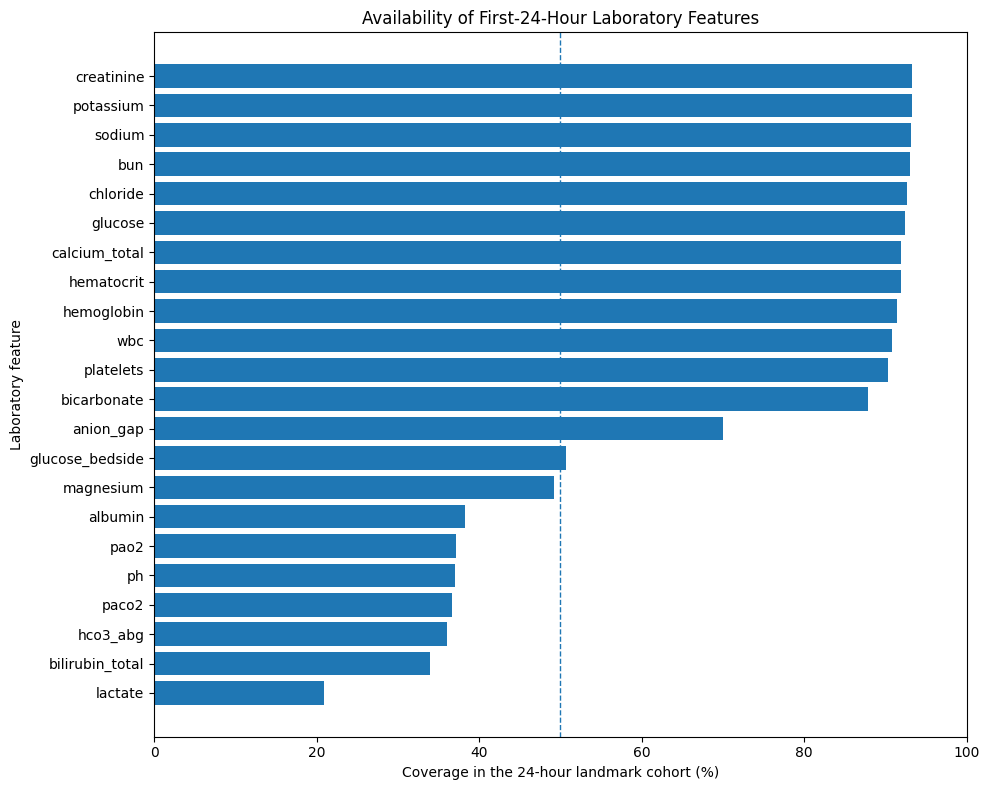

In [72]:
import matplotlib.pyplot as plt


plot_data = (
    lab_coverage_summary
    .sort_values(
        "coverage_percent",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    plot_data["lab_feature"],
    plot_data["coverage_percent"],
)

ax.axvline(
    50,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Coverage in the 24-hour landmark cohort (%)"
)

ax.set_ylabel(
    "Laboratory feature"
)

ax.set_title(
    "Availability of First-24-Hour Laboratory Features"
)

ax.set_xlim(0, 100)

fig.tight_layout()


LAB_COVERAGE_FIGURE = (
    FIGURE_DIR
    / "lab_first24h_coverage.png"
)

fig.savefig(
    LAB_COVERAGE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Validation cell

In [77]:
assert lab_features.shape[0] == 1_389
assert lab_features["patientunitstayid"].is_unique
assert len(lab_feature_columns) == 110
assert int(lab_features["lab_any_available"].sum()) == 1_349
assert int((lab_features["lab_any_available"] == 0).sum()) == 40

print("Laboratory feature block validated successfully.")

Laboratory feature block validated successfully.


#### Saving a laboratory feature manifest

In [78]:
import pandas as pd

from config.paths import COHORT_DIR


lab_feature_manifest = pd.DataFrame(
    {
        "feature": lab_feature_columns,
    }
)

lab_feature_manifest["statistic"] = (
    lab_feature_manifest["feature"]
    .str.extract(
        r"_(first|median|min|max|measurement_count)$",
        expand=False,
    )
)

lab_feature_manifest["laboratory"] = (
    lab_feature_manifest["feature"]
    .str.replace(
        r"^lab_",
        "",
        regex=True,
    )
    .str.replace(
        r"_(first|median|min|max|measurement_count)$",
        "",
        regex=True,
    )
)

lab_feature_manifest["feature_group"] = "laboratory"

lab_feature_manifest["primary_model_candidate"] = (
    lab_feature_manifest["statistic"]
    .isin(
        [
            "first",
            "median",
            "min",
            "max",
        ]
    )
)

manifest_file = (
    COHORT_DIR
    / "qc"
    / "lab_feature_manifest.csv"
)

lab_feature_manifest.to_csv(
    manifest_file,
    index=False,
)

print(f"Saved to: {manifest_file}")

Saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\lab_feature_manifest.csv


#### Validating the header for vitalPeriodic

In [79]:
import pandas as pd

from config.paths import FULL_DATA_DIR


VITAL_PERIODIC_FILE = (
    FULL_DATA_DIR
    / "vitalPeriodic.csv"
)

VITAL_PERIODIC_COLUMNS = [
    "patientunitstayid",
    "observationoffset",
    "temperature",
    "sao2",
    "heartrate",
    "respiration",
    "systemicsystolic",
    "systemicdiastolic",
    "systemicmean",
    "etco2",
]


vital_header = pd.read_csv(
    VITAL_PERIODIC_FILE,
    nrows=0,
)

missing_columns = set(
    VITAL_PERIODIC_COLUMNS
).difference(
    vital_header.columns
)

if missing_columns:
    raise KeyError(
        "Missing vitalPeriodic columns: "
        + ", ".join(sorted(missing_columns))
    )

print("vitalPeriodic header validation passed.")
print(f"File: {VITAL_PERIODIC_FILE}")

vitalPeriodic header validation passed.
File: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\data\full\vitalPeriodic.csv


#### Extracting the landmark cohort’s first 24 hours for vitalPeriodic

In [80]:
import pandas as pd

from config.paths import REDUCED_DATA_DIR


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

VITAL_PERIODIC_FIRST24H_FILE = (
    REDUCED_DATA_DIR
    / "vital_periodic_landmark_first24h_raw.csv"
)

CHUNK_SIZE = 1_000_000


landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

landmark_ids["patientunitstayid"] = pd.to_numeric(
    landmark_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

landmark_id_set = set(
    landmark_ids["patientunitstayid"]
)

assert len(landmark_id_set) == 1_389

#### Running the extraction

In [81]:
if VITAL_PERIODIC_FIRST24H_FILE.exists():
    VITAL_PERIODIC_FIRST24H_FILE.unlink()


total_source_rows = 0
total_retained_rows = 0
covered_ids: set[int] = set()
first_write = True


reader = pd.read_csv(
    VITAL_PERIODIC_FILE,
    usecols=VITAL_PERIODIC_COLUMNS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)


for chunk_number, chunk in enumerate(
    reader,
    start=1,
):
    total_source_rows += len(chunk)

    chunk["patientunitstayid"] = pd.to_numeric(
        chunk["patientunitstayid"],
        errors="coerce",
    )

    chunk["observationoffset"] = pd.to_numeric(
        chunk["observationoffset"],
        errors="coerce",
    )

    mask = (
        chunk["patientunitstayid"].isin(
            landmark_id_set
        )
        & chunk["observationoffset"].between(
            0,
            1440,
            inclusive="both",
        )
    )

    selected = chunk.loc[
        mask,
        VITAL_PERIODIC_COLUMNS,
    ].copy()

    if selected.empty:
        continue

    selected["patientunitstayid"] = (
        selected["patientunitstayid"]
        .astype("int64")
    )

    selected["observationoffset"] = (
        selected["observationoffset"]
        .astype("int64")
    )

    selected.to_csv(
        VITAL_PERIODIC_FIRST24H_FILE,
        mode="w" if first_write else "a",
        header=first_write,
        index=False,
    )

    first_write = False
    total_retained_rows += len(selected)

    covered_ids.update(
        selected["patientunitstayid"]
        .unique()
        .tolist()
    )

    print(
        f"Chunk {chunk_number}: "
        f"{len(selected):,} rows retained"
    )


if first_write:
    raise RuntimeError(
        "No eligible vitalPeriodic records were found."
    )


print("\nExtraction completed.")
print(f"Source rows scanned: {total_source_rows:,}")
print(f"Rows retained: {total_retained_rows:,}")
print(
    "Landmark stays with vitalPeriodic data:",
    f"{len(covered_ids):,}",
)
print(
    "Coverage:",
    f"{100 * len(covered_ids) / len(landmark_id_set):.2f}%"
)
print(f"Saved privately to: {VITAL_PERIODIC_FIRST24H_FILE}")

Chunk 1: 4,281 rows retained
Chunk 2: 2,293 rows retained
Chunk 3: 2,813 rows retained
Chunk 4: 1,976 rows retained
Chunk 5: 1,988 rows retained
Chunk 6: 2,000 rows retained
Chunk 7: 2,483 rows retained
Chunk 8: 1,873 rows retained
Chunk 9: 2,261 rows retained
Chunk 10: 2,981 rows retained
Chunk 11: 2,922 rows retained
Chunk 12: 6,148 rows retained
Chunk 13: 5,295 rows retained
Chunk 14: 6,468 rows retained
Chunk 15: 4,957 rows retained
Chunk 16: 4,730 rows retained
Chunk 17: 4,634 rows retained
Chunk 18: 4,410 rows retained
Chunk 19: 4,482 rows retained
Chunk 20: 3,122 rows retained
Chunk 21: 1,702 rows retained
Chunk 22: 1,995 rows retained
Chunk 23: 2,255 rows retained
Chunk 24: 3,039 rows retained
Chunk 25: 2,770 rows retained
Chunk 26: 844 rows retained
Chunk 27: 3,040 rows retained
Chunk 28: 1,975 rows retained
Chunk 29: 858 rows retained
Chunk 30: 2,112 rows retained
Chunk 31: 1,949 rows retained
Chunk 32: 2,197 rows retained
Chunk 33: 1,124 rows retained
Chunk 34: 1,680 rows re

In [82]:
print(f"Full source file: {VITAL_PERIODIC_FILE.resolve()}")
print(
    "Reduced output file:",
    VITAL_PERIODIC_FIRST24H_FILE.resolve(),
)

assert (
    VITAL_PERIODIC_FILE.resolve()
    != VITAL_PERIODIC_FIRST24H_FILE.resolve()
)

if "total_source_rows" in globals():
    print(
        "Actual source rows scanned:",
        f"{total_source_rows:,}",
    )
else:
    print(
        "The source-row counter is no longer in memory. "
        "There is no need to rescan the file."
    )

print(
    "Rows retained in reduced file:",
    f"{sum(1 for _ in open(VITAL_PERIODIC_FIRST24H_FILE, encoding='utf-8')) - 1:,}",
)

Full source file: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\data\full\vitalPeriodic.csv
Reduced output file: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\vital_periodic_landmark_first24h_raw.csv
Actual source rows scanned: 146,671,642
Rows retained in reduced file: 380,260


#### Defining paths and technical ranges for vitalPeriodic

In [83]:
from __future__ import annotations

import pandas as pd

from config.paths import (
    COHORT_DIR,
    FIGURE_DIR,
    REDUCED_DATA_DIR,
)


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

VITAL_PERIODIC_RAW_FILE = (
    REDUCED_DATA_DIR
    / "vital_periodic_landmark_first24h_raw.csv"
)

VITAL_PERIODIC_FEATURES_CSV = (
    REDUCED_DATA_DIR
    / "vital_periodic_first24h_features_v001.csv"
)

VITAL_PERIODIC_FEATURES_PARQUET = (
    REDUCED_DATA_DIR
    / "vital_periodic_first24h_features_v001.parquet"
)

QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


VITAL_PERIODIC_RANGES = {
    # Broad technical plausibility limits, not normal ranges
    "temperature": (25.0, 45.0),
    "sao2": (30.0, 100.0),
    "heartrate": (15.0, 300.0),
    "respiration": (2.0, 100.0),
    "systemicsystolic": (30.0, 300.0),
    "systemicdiastolic": (10.0, 200.0),
    "systemicmean": (20.0, 250.0),
    "etco2": (2.0, 150.0),
}

#### Loading and validating the reduced data

In [84]:
landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

landmark_ids["patientunitstayid"] = pd.to_numeric(
    landmark_ids["patientunitstayid"],
    errors="raise",
).astype("int64")


vital_periodic_raw = pd.read_csv(
    VITAL_PERIODIC_RAW_FILE,
    low_memory=False,
)

vital_periodic_raw["patientunitstayid"] = pd.to_numeric(
    vital_periodic_raw["patientunitstayid"],
    errors="raise",
).astype("int64")

vital_periodic_raw["observationoffset"] = pd.to_numeric(
    vital_periodic_raw["observationoffset"],
    errors="raise",
).astype("int64")


landmark_id_set = set(
    landmark_ids["patientunitstayid"]
)

assert len(landmark_ids) == 1_389
assert landmark_ids["patientunitstayid"].is_unique

assert set(
    vital_periodic_raw["patientunitstayid"].unique()
).issubset(landmark_id_set)

assert vital_periodic_raw[
    "observationoffset"
].between(
    0,
    1440,
    inclusive="both",
).all()


print(
    "Reduced periodic-vital rows:",
    f"{len(vital_periodic_raw):,}",
)

print(
    "Covered ICU stays:",
    f"{vital_periodic_raw['patientunitstayid'].nunique():,}",
)

Reduced periodic-vital rows: 380,260
Covered ICU stays: 1,370


#### Creating a reusable aggregation function

In [85]:
def aggregate_periodic_vital(
    dataframe: pd.DataFrame,
    feature: str,
    lower_bound: float,
    upper_bound: float,
) -> tuple[pd.DataFrame, dict[str, object]]:
    """
    Clean and aggregate one periodic vital sign.

    Duplicate readings recorded at the same observation offset are first
    collapsed using their median.
    """

    feature_data = dataframe[
        [
            "patientunitstayid",
            "observationoffset",
            feature,
        ]
    ].copy()

    original_nonmissing = feature_data[
        feature
    ].notna()

    feature_data["value"] = pd.to_numeric(
        feature_data[feature],
        errors="coerce",
    )

    nonnumeric = (
        original_nonmissing
        & feature_data["value"].isna()
    )

    in_range = (
        feature_data["value"].notna()
        & feature_data["value"].between(
            lower_bound,
            upper_bound,
            inclusive="both",
        )
    )

    out_of_range = (
        feature_data["value"].notna()
        & ~in_range
    )

    valid = feature_data.loc[
        in_range,
        [
            "patientunitstayid",
            "observationoffset",
            "value",
        ],
    ].copy()

    # Collapse duplicate measurements at the same minute
    valid_at_offset = (
        valid
        .groupby(
            [
                "patientunitstayid",
                "observationoffset",
            ],
            as_index=False,
        )
        .agg(
            value=("value", "median"),
        )
    )

    aggregated = (
        valid_at_offset
        .sort_values(
            [
                "patientunitstayid",
                "observationoffset",
            ]
        )
        .groupby(
            "patientunitstayid"
        )["value"]
        .agg(
            first="first",
            median="median",
            min="min",
            max="max",
            std="std",
            measurement_count="size",
        )
        .reset_index()
    )

    aggregated = aggregated.rename(
        columns={
            statistic: (
                f"vital_periodic_"
                f"{feature}_{statistic}"
            )
            for statistic in (
                "first",
                "median",
                "min",
                "max",
                "std",
                "measurement_count",
            )
        }
    )

    audit = {
        "vital_feature": feature,
        "raw_rows": len(feature_data),
        "raw_nonmissing_records": int(
            original_nonmissing.sum()
        ),
        "nonnumeric_records": int(
            nonnumeric.sum()
        ),
        "out_of_range_records": int(
            out_of_range.sum()
        ),
        "valid_records": len(valid),
        "valid_offset_records": len(valid_at_offset),
        "unique_icu_stays": (
            valid_at_offset[
                "patientunitstayid"
            ].nunique()
        ),
    }

    return aggregated, audit

#### Aggregating all periodic vital signs

In [86]:
vital_feature_blocks: list[pd.DataFrame] = []
vital_audit_records: list[dict[str, object]] = []


for feature, bounds in VITAL_PERIODIC_RANGES.items():
    lower_bound, upper_bound = bounds

    feature_block, feature_audit = (
        aggregate_periodic_vital(
            dataframe=vital_periodic_raw,
            feature=feature,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
        )
    )

    vital_feature_blocks.append(
        feature_block
    )

    vital_audit_records.append(
        feature_audit
    )

    print(
        f"{feature}: "
        f"{feature_audit['unique_icu_stays']:,} "
        "covered stays"
    )

temperature: 100 covered stays
sao2: 1,365 covered stays
heartrate: 1,370 covered stays
respiration: 1,223 covered stays
systemicsystolic: 517 covered stays
systemicdiastolic: 517 covered stays
systemicmean: 518 covered stays
etco2: 55 covered stays


#### Merging them into one row per landmark patient

In [87]:
vital_periodic_features = (
    landmark_ids.copy()
)


for feature_block in vital_feature_blocks:
    vital_periodic_features = (
        vital_periodic_features.merge(
            feature_block,
            on="patientunitstayid",
            how="left",
            validate="one_to_one",
        )
    )


periodic_feature_columns = [
    column
    for column in vital_periodic_features.columns
    if column != "patientunitstayid"
]


vital_periodic_features[
    "vital_periodic_any_available"
] = (
    vital_periodic_features[
        periodic_feature_columns
    ]
    .notna()
    .any(axis=1)
    .astype("int8")
)


assert len(vital_periodic_features) == 1_389

assert vital_periodic_features[
    "patientunitstayid"
].is_unique

#### Exporting the private feature matrix

In [88]:
vital_periodic_features.to_csv(
    VITAL_PERIODIC_FEATURES_CSV,
    index=False,
)

vital_periodic_features.to_parquet(
    VITAL_PERIODIC_FEATURES_PARQUET,
    index=False,
    engine="pyarrow",
)

print(
    f"CSV saved to: {VITAL_PERIODIC_FEATURES_CSV}"
)

print(
    f"Parquet saved to: {VITAL_PERIODIC_FEATURES_PARQUET}"
)

CSV saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\vital_periodic_first24h_features_v001.csv
Parquet saved to: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\vital_periodic_first24h_features_v001.parquet


#### Generating the privacy-safe QC summary

In [89]:
vital_periodic_qc = pd.DataFrame(
    vital_audit_records
)

vital_periodic_qc["coverage_percent"] = (
    100
    * vital_periodic_qc["unique_icu_stays"]
    / len(landmark_ids)
)

vital_periodic_qc[
    "out_of_range_percent"
] = (
    100
    * vital_periodic_qc[
        "out_of_range_records"
    ]
    / vital_periodic_qc[
        "raw_nonmissing_records"
    ].replace(0, pd.NA)
)

vital_periodic_qc = (
    vital_periodic_qc
    .sort_values(
        "coverage_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)


VITAL_PERIODIC_QC_FILE = (
    QC_DIR
    / "vital_periodic_cleaning_coverage_summary.csv"
)

vital_periodic_qc.to_csv(
    VITAL_PERIODIC_QC_FILE,
    index=False,
)

display(vital_periodic_qc)

print(f"QC summary: {VITAL_PERIODIC_QC_FILE}")

,vital_feature,raw_rows,raw_nonmissing_records,nonnumeric_records,out_of_range_records,valid_records,valid_offset_records,unique_icu_stays,coverage_percent,out_of_range_percent
0,heartrate,380260,379577,0,17,379560,379560,1370,98.632109,0.004479
1,sao2,380260,360932,0,10,360922,360922,1365,98.272138,0.002771
2,respiration,380260,328224,0,2438,325786,325786,1223,88.048956,0.742785
3,systemicmean,380260,109074,0,984,108090,108090,518,37.293017,0.902140
4,systemicdiastolic,380260,107742,0,318,107424,107424,517,37.221022,0.295150
5,systemicsystolic,380260,107741,0,229,107512,107512,517,37.221022,0.212547
6,temperature,380260,23031,0,398,22633,22633,100,7.199424,1.728106
7,etco2,380260,10050,0,13,10037,10037,55,3.959683,0.129353


QC summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\vital_periodic_cleaning_coverage_summary.csv


#### Printing the feature-block summary

In [90]:
periodic_model_columns = [
    column
    for column in vital_periodic_features.columns
    if column not in {
        "patientunitstayid",
        "vital_periodic_any_available",
    }
]

patients_with_periodic_vitals = int(
    vital_periodic_features[
        "vital_periodic_any_available"
    ].sum()
)

patients_without_periodic_vitals = (
    len(vital_periodic_features)
    - patients_with_periodic_vitals
)


print(
    "Rows in vital_periodic_features:",
    f"{len(vital_periodic_features):,}",
)

print(
    "Number of periodic-vital feature columns:",
    f"{len(periodic_model_columns):,}",
)

print(
    "Patients with at least one valid periodic vital:",
    f"{patients_with_periodic_vitals:,}",
)

print(
    "Patients without valid periodic vitals:",
    f"{patients_without_periodic_vitals:,}",
)

print(
    "Valid periodic-vital coverage:",
    (
        f"{100 * patients_with_periodic_vitals / len(vital_periodic_features):.2f}%"
    ),
)

Rows in vital_periodic_features: 1,389
Number of periodic-vital feature columns: 48
Patients with at least one valid periodic vital: 1,370
Patients without valid periodic vitals: 19
Valid periodic-vital coverage: 98.63%


#### Creating the coverage figure

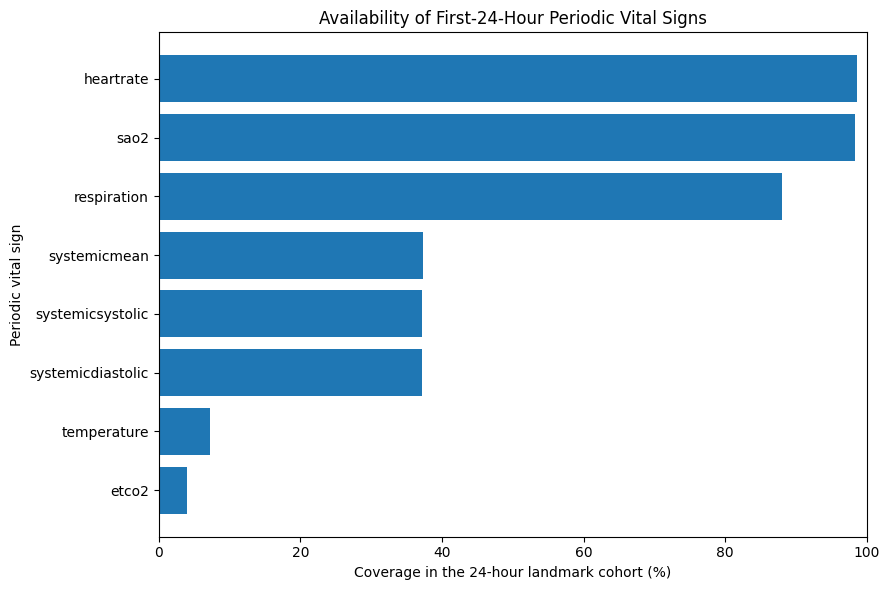

In [108]:
import matplotlib.pyplot as plt


plot_data = (
    vital_periodic_qc
    .sort_values(
        "coverage_percent",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    plot_data["vital_feature"],
    plot_data["coverage_percent"],
)

ax.set_xlabel(
    "Coverage in the 24-hour landmark cohort (%)"
)

ax.set_ylabel(
    "Periodic vital sign"
)

ax.set_title(
    "Availability of First-24-Hour Periodic Vital Signs"
)

ax.set_xlim(0, 100)

fig.tight_layout()


VITAL_PERIODIC_FIGURE = (
    FIGURE_DIR
    / "vital_periodic_first24h_coverage.png"
)

fig.savefig(
    VITAL_PERIODIC_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Validating the header for vitalAperiodic

In [91]:
import pandas as pd

from config.paths import FULL_DATA_DIR


VITAL_APERIODIC_FILE = (
    FULL_DATA_DIR / "vitalAperiodic.csv"
)

VITAL_APERIODIC_COLUMNS = [
    "patientunitstayid",
    "observationoffset",
    "noninvasivesystolic",
    "noninvasivediastolic",
    "noninvasivemean",
]


header = pd.read_csv(
    VITAL_APERIODIC_FILE,
    nrows=0,
)

missing_columns = set(
    VITAL_APERIODIC_COLUMNS
).difference(header.columns)

if missing_columns:
    raise KeyError(
        "Missing vitalAperiodic columns: "
        + ", ".join(sorted(missing_columns))
    )

print("vitalAperiodic header validation passed.")
print(f"File: {VITAL_APERIODIC_FILE}")

vitalAperiodic header validation passed.
File: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\data\full\vitalAperiodic.csv


#### Extracting the landmark cohort’s first 24 hours

In [92]:
import pandas as pd

from config.paths import REDUCED_DATA_DIR


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

VITAL_APERIODIC_RAW_FILE = (
    REDUCED_DATA_DIR
    / "vital_aperiodic_landmark_first24h_raw.csv"
)

CHUNK_SIZE = 1_000_000


landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

landmark_ids["patientunitstayid"] = pd.to_numeric(
    landmark_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

landmark_id_set = set(
    landmark_ids["patientunitstayid"]
)

assert len(landmark_id_set) == 1_389

#### Running the chunked extraction

In [93]:
if VITAL_APERIODIC_RAW_FILE.exists():
    VITAL_APERIODIC_RAW_FILE.unlink()


total_source_rows = 0
total_retained_rows = 0
covered_ids: set[int] = set()
first_write = True

bp_columns = [
    "noninvasivesystolic",
    "noninvasivediastolic",
    "noninvasivemean",
]


reader = pd.read_csv(
    VITAL_APERIODIC_FILE,
    usecols=VITAL_APERIODIC_COLUMNS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)


for chunk_number, chunk in enumerate(reader, start=1):
    total_source_rows += len(chunk)

    chunk["patientunitstayid"] = pd.to_numeric(
        chunk["patientunitstayid"],
        errors="coerce",
    )

    chunk["observationoffset"] = pd.to_numeric(
        chunk["observationoffset"],
        errors="coerce",
    )

    mask = (
        chunk["patientunitstayid"].isin(
            landmark_id_set
        )
        & chunk["observationoffset"].between(
            0,
            1440,
            inclusive="both",
        )
    )

    selected = chunk.loc[
        mask,
        VITAL_APERIODIC_COLUMNS,
    ].copy()

    # Remove rows that contain no selected BP measurement
    selected = selected.loc[
        selected[bp_columns]
        .notna()
        .any(axis=1)
    ].copy()

    if selected.empty:
        continue

    selected["patientunitstayid"] = (
        selected["patientunitstayid"]
        .astype("int64")
    )

    selected["observationoffset"] = (
        selected["observationoffset"]
        .astype("int64")
    )

    selected.to_csv(
        VITAL_APERIODIC_RAW_FILE,
        mode="w" if first_write else "a",
        header=first_write,
        index=False,
    )

    first_write = False
    total_retained_rows += len(selected)

    covered_ids.update(
        selected["patientunitstayid"]
        .unique()
        .tolist()
    )

    print(
        f"Chunk {chunk_number}: "
        f"{len(selected):,} rows retained"
    )


if first_write:
    raise RuntimeError(
        "No eligible vitalAperiodic records were found."
    )


print("\nExtraction completed.")
print(f"Source rows scanned: {total_source_rows:,}")
print(f"First-24-hour rows retained: {total_retained_rows:,}")
print(
    "Landmark stays with aperiodic BP data:",
    f"{len(covered_ids):,}",
)
print(
    "Raw coverage:",
    f"{100 * len(covered_ids) / len(landmark_id_set):.2f}%"
)
print(f"Saved privately to: {VITAL_APERIODIC_RAW_FILE}")

Chunk 1: 2,954 rows retained
Chunk 2: 4,029 rows retained
Chunk 3: 4,361 rows retained
Chunk 4: 3,324 rows retained
Chunk 5: 2,176 rows retained
Chunk 6: 1,856 rows retained
Chunk 7: 2,861 rows retained
Chunk 8: 1,736 rows retained
Chunk 9: 1,936 rows retained
Chunk 10: 3,552 rows retained
Chunk 11: 4,009 rows retained
Chunk 12: 1,009 rows retained
Chunk 13: 2,970 rows retained
Chunk 14: 1,514 rows retained
Chunk 15: 2,304 rows retained
Chunk 16: 1,638 rows retained
Chunk 17: 1,776 rows retained
Chunk 18: 3,333 rows retained
Chunk 19: 2,917 rows retained
Chunk 20: 2,811 rows retained
Chunk 21: 632 rows retained
Chunk 22: 3,784 rows retained
Chunk 23: 4,268 rows retained
Chunk 24: 2,502 rows retained
Chunk 25: 2,577 rows retained
Chunk 26: 116 rows retained

Extraction completed.
Source rows scanned: 25,075,074
First-24-hour rows retained: 66,945
Landmark stays with aperiodic BP data: 1,358
Raw coverage: 97.77%
Saved privately to: D:\Spain\Online Courses\10. Data Analysis Specialization

#### Cleaning non-invasive blood pressure

In [94]:
NIBP_RANGES = {
    "noninvasivesystolic": (40.0, 300.0),
    "noninvasivediastolic": (10.0, 200.0),
    "noninvasivemean": (20.0, 250.0),
    "noninvasivepulsepressure": (5.0, 200.0),
}

#### Loading the reduced file

In [95]:
vital_aperiodic_raw = pd.read_csv(
    VITAL_APERIODIC_RAW_FILE,
    low_memory=False,
)

vital_aperiodic_raw["patientunitstayid"] = pd.to_numeric(
    vital_aperiodic_raw["patientunitstayid"],
    errors="raise",
).astype("int64")

vital_aperiodic_raw["observationoffset"] = pd.to_numeric(
    vital_aperiodic_raw["observationoffset"],
    errors="raise",
).astype("int64")


assert set(
    vital_aperiodic_raw[
        "patientunitstayid"
    ].unique()
).issubset(landmark_id_set)

assert vital_aperiodic_raw[
    "observationoffset"
].between(
    0,
    1440,
    inclusive="both",
).all()

#### Converting the measurements

In [96]:
source_bp_columns = [
    "noninvasivesystolic",
    "noninvasivediastolic",
    "noninvasivemean",
]

original_nonmissing = {
    column: vital_aperiodic_raw[column].notna()
    for column in source_bp_columns
}

for column in source_bp_columns:
    vital_aperiodic_raw[column] = pd.to_numeric(
        vital_aperiodic_raw[column],
        errors="coerce",
    )

#### Applying range checks

In [97]:
systolic_raw = (
    vital_aperiodic_raw[
        "noninvasivesystolic"
    ]
)

diastolic_raw = (
    vital_aperiodic_raw[
        "noninvasivediastolic"
    ]
)

mean_raw = (
    vital_aperiodic_raw[
        "noninvasivemean"
    ]
)


systolic_in_range = systolic_raw.between(
    40,
    300,
    inclusive="both",
)

diastolic_in_range = diastolic_raw.between(
    10,
    200,
    inclusive="both",
)

mean_in_range = mean_raw.between(
    20,
    250,
    inclusive="both",
)

#### Checking physiological ordering

In [98]:
invalid_systolic_diastolic_pair = (
    systolic_in_range
    & diastolic_in_range
    & systolic_raw.le(diastolic_raw)
)


vital_aperiodic_raw["nibp_systolic"] = (
    systolic_raw.where(
        systolic_in_range
        & ~invalid_systolic_diastolic_pair
    )
)

vital_aperiodic_raw["nibp_diastolic"] = (
    diastolic_raw.where(
        diastolic_in_range
        & ~invalid_systolic_diastolic_pair
    )
)

#### Validating mean pressure when all three values are present

In [99]:
invalid_mean_relationship = (
    mean_in_range
    & vital_aperiodic_raw[
        "nibp_systolic"
    ].notna()
    & vital_aperiodic_raw[
        "nibp_diastolic"
    ].notna()
    & (
        mean_raw.lt(
            vital_aperiodic_raw[
                "nibp_diastolic"
            ]
        )
        | mean_raw.gt(
            vital_aperiodic_raw[
                "nibp_systolic"
            ]
        )
    )
)


vital_aperiodic_raw["nibp_mean"] = (
    mean_raw.where(
        mean_in_range
        & ~invalid_mean_relationship
    )
)

#### Deriving pulse pressure

In [100]:
pulse_pressure_raw = (
    vital_aperiodic_raw[
        "nibp_systolic"
    ]
    - vital_aperiodic_raw[
        "nibp_diastolic"
    ]
)


vital_aperiodic_raw[
    "nibp_pulse_pressure"
] = pulse_pressure_raw.where(
    pulse_pressure_raw.between(
        5,
        200,
        inclusive="both",
    )
)

#### Aggregating the first 24 hours

In [101]:
def aggregate_aperiodic_feature(
    dataframe: pd.DataFrame,
    feature: str,
) -> pd.DataFrame:
    """
    Aggregate one first-24-hour aperiodic measurement.
    """

    valid = dataframe.loc[
        dataframe[feature].notna(),
        [
            "patientunitstayid",
            "observationoffset",
            feature,
        ],
    ].copy()

    # Collapse same-minute duplicate readings
    valid_at_offset = (
        valid
        .groupby(
            [
                "patientunitstayid",
                "observationoffset",
            ],
            as_index=False,
        )
        .agg(
            value=(feature, "median"),
        )
    )

    aggregated = (
        valid_at_offset
        .sort_values(
            [
                "patientunitstayid",
                "observationoffset",
            ]
        )
        .groupby(
            "patientunitstayid"
        )["value"]
        .agg(
            first="first",
            median="median",
            min="min",
            max="max",
            std="std",
            measurement_count="size",
        )
        .reset_index()
    )

    aggregated = aggregated.rename(
        columns={
            statistic: (
                f"vital_aperiodic_"
                f"{feature}_{statistic}"
            )
            for statistic in (
                "first",
                "median",
                "min",
                "max",
                "std",
                "measurement_count",
            )
        }
    )

    return aggregated

#### Aggregating all four features

In [102]:
APERIODIC_FEATURES = [
    "nibp_systolic",
    "nibp_diastolic",
    "nibp_mean",
    "nibp_pulse_pressure",
]


feature_blocks = [
    aggregate_aperiodic_feature(
        vital_aperiodic_raw,
        feature,
    )
    for feature in APERIODIC_FEATURES
]

#### Merging them into one row per landmark patient

In [103]:
vital_aperiodic_features = (
    landmark_ids.copy()
)


for feature_block in feature_blocks:
    vital_aperiodic_features = (
        vital_aperiodic_features.merge(
            feature_block,
            on="patientunitstayid",
            how="left",
            validate="one_to_one",
        )
    )


aperiodic_feature_columns = [
    column
    for column
    in vital_aperiodic_features.columns
    if column != "patientunitstayid"
]


vital_aperiodic_features[
    "vital_aperiodic_any_available"
] = (
    vital_aperiodic_features[
        aperiodic_feature_columns
    ]
    .notna()
    .any(axis=1)
    .astype("int8")
)


assert len(vital_aperiodic_features) == 1_389

assert vital_aperiodic_features[
    "patientunitstayid"
].is_unique

#### Exporting privately

In [104]:
from config.paths import REDUCED_DATA_DIR


VITAL_APERIODIC_FEATURES_CSV = (
    REDUCED_DATA_DIR
    / "vital_aperiodic_first24h_features_v001.csv"
)

VITAL_APERIODIC_FEATURES_PARQUET = (
    REDUCED_DATA_DIR
    / "vital_aperiodic_first24h_features_v001.parquet"
)


vital_aperiodic_features.to_csv(
    VITAL_APERIODIC_FEATURES_CSV,
    index=False,
)

vital_aperiodic_features.to_parquet(
    VITAL_APERIODIC_FEATURES_PARQUET,
    index=False,
    engine="pyarrow",
)

#### Generating the privacy-safe QC summary

In [105]:
audit_rows = []


for feature in APERIODIC_FEATURES:
    valid_mask = (
        vital_aperiodic_raw[feature].notna()
    )

    audit_rows.append(
        {
            "vital_feature": feature,
            "valid_records": int(
                valid_mask.sum()
            ),
            "unique_icu_stays": int(
                vital_aperiodic_raw.loc[
                    valid_mask,
                    "patientunitstayid",
                ].nunique()
            ),
        }
    )


vital_aperiodic_qc = pd.DataFrame(
    audit_rows
)


vital_aperiodic_qc[
    "coverage_percent"
] = (
    100
    * vital_aperiodic_qc[
        "unique_icu_stays"
    ]
    / len(landmark_ids)
)


vital_aperiodic_qc[
    "invalid_systolic_diastolic_pairs"
] = int(
    invalid_systolic_diastolic_pair.sum()
)

vital_aperiodic_qc[
    "invalid_mean_relationships"
] = int(
    invalid_mean_relationship.sum()
)


QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

VITAL_APERIODIC_QC_FILE = (
    QC_DIR
    / "vital_aperiodic_cleaning_coverage_summary.csv"
)

vital_aperiodic_qc.to_csv(
    VITAL_APERIODIC_QC_FILE,
    index=False,
)

display(vital_aperiodic_qc)

print(f"QC summary: {VITAL_APERIODIC_QC_FILE}")

,vital_feature,valid_records,unique_icu_stays,coverage_percent,invalid_systolic_diastolic_pairs,invalid_mean_relationships
0,nibp_systolic,66241,1357,97.696184,0,1
1,nibp_diastolic,66250,1357,97.696184,0,1
2,nibp_mean,66799,1358,97.768179,0,1
3,nibp_pulse_pressure,66181,1357,97.696184,0,1


QC summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\vital_aperiodic_cleaning_coverage_summary.csv


#### Printing the feature-block summary

In [106]:
aperiodic_model_columns = [
    column
    for column
    in vital_aperiodic_features.columns
    if column not in {
        "patientunitstayid",
        "vital_aperiodic_any_available",
    }
]


patients_with_aperiodic_vitals = int(
    vital_aperiodic_features[
        "vital_aperiodic_any_available"
    ].sum()
)

patients_without_aperiodic_vitals = (
    len(vital_aperiodic_features)
    - patients_with_aperiodic_vitals
)


print(
    "Rows in vital_aperiodic_features:",
    f"{len(vital_aperiodic_features):,}",
)

print(
    "Number of aperiodic-vital feature columns:",
    f"{len(aperiodic_model_columns):,}",
)

print(
    "Patients with at least one valid aperiodic vital:",
    f"{patients_with_aperiodic_vitals:,}",
)

print(
    "Patients without valid aperiodic vitals:",
    f"{patients_without_aperiodic_vitals:,}",
)

print(
    "Valid aperiodic-vital coverage:",
    (
        f"{100 * patients_with_aperiodic_vitals / len(vital_aperiodic_features):.2f}%"
    ),
)

Rows in vital_aperiodic_features: 1,389
Number of aperiodic-vital feature columns: 24
Patients with at least one valid aperiodic vital: 1,358
Patients without valid aperiodic vitals: 31
Valid aperiodic-vital coverage: 97.77%


#### Creating the coverage figure

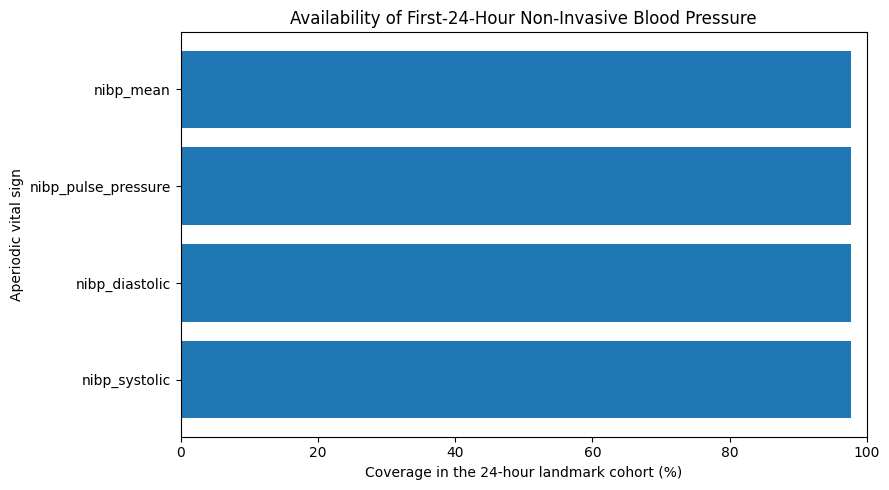

In [107]:
import matplotlib.pyplot as plt


plot_data = (
    vital_aperiodic_qc
    .sort_values(
        "coverage_percent",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    plot_data["vital_feature"],
    plot_data["coverage_percent"],
)

ax.set_xlabel(
    "Coverage in the 24-hour landmark cohort (%)"
)

ax.set_ylabel(
    "Aperiodic vital sign"
)

ax.set_title(
    "Availability of First-24-Hour Non-Invasive Blood Pressure"
)

ax.set_xlim(0, 100)

fig.tight_layout()


figure_file = (
    FIGURE_DIR
    / "vital_aperiodic_first24h_coverage.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Combining both vital-sign feature blocks

#### Loading the landmark IDs and feature files

In [110]:
import pandas as pd

from config.paths import (
    COHORT_DIR,
    FIGURE_DIR,
    REDUCED_DATA_DIR,
)


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

VITAL_PERIODIC_FEATURES_FILE = (
    REDUCED_DATA_DIR
    / "vital_periodic_first24h_features_v001.csv"
)

VITAL_APERIODIC_FEATURES_FILE = (
    REDUCED_DATA_DIR
    / "vital_aperiodic_first24h_features_v001.csv"
)


landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

vital_periodic = pd.read_csv(
    VITAL_PERIODIC_FEATURES_FILE,
    low_memory=False,
)

vital_aperiodic = pd.read_csv(
    VITAL_APERIODIC_FEATURES_FILE,
    low_memory=False,
)


for dataframe in (
    landmark_ids,
    vital_periodic,
    vital_aperiodic,
):
    dataframe["patientunitstayid"] = pd.to_numeric(
        dataframe["patientunitstayid"],
        errors="raise",
    ).astype("int64")

#### Validating both input blocks

In [111]:
assert len(landmark_ids) == 1_389
assert landmark_ids["patientunitstayid"].is_unique

assert len(vital_periodic) == 1_389
assert vital_periodic["patientunitstayid"].is_unique

assert len(vital_aperiodic) == 1_389
assert vital_aperiodic["patientunitstayid"].is_unique

assert set(
    vital_periodic["patientunitstayid"]
) == set(
    landmark_ids["patientunitstayid"]
)

assert set(
    vital_aperiodic["patientunitstayid"]
) == set(
    landmark_ids["patientunitstayid"]
)

print("Both vital-sign feature blocks passed validation.")

Both vital-sign feature blocks passed validation.


#### Merging all periodic and aperiodic features

In [112]:
vital_all_features = (
    landmark_ids
    .merge(
        vital_periodic,
        on="patientunitstayid",
        how="left",
        validate="one_to_one",
    )
    .merge(
        vital_aperiodic,
        on="patientunitstayid",
        how="left",
        validate="one_to_one",
    )
)


vital_all_features["vital_any_available"] = (
    (
        vital_all_features[
            "vital_periodic_any_available"
        ].eq(1)
        |
        vital_all_features[
            "vital_aperiodic_any_available"
        ].eq(1)
    )
    .astype("int8")
)


assert len(vital_all_features) == 1_389

assert vital_all_features[
    "patientunitstayid"
].is_unique

#### Creating the primary vital-sign feature block

In [113]:
PRIMARY_PERIODIC_VITALS = [
    "heartrate",
    "respiration",
    "sao2",
]

PRIMARY_APERIODIC_VITALS = [
    "nibp_systolic",
    "nibp_diastolic",
    "nibp_mean",
    "nibp_pulse_pressure",
]

PRIMARY_VITAL_STATISTICS = [
    "first",
    "median",
    "min",
    "max",
    "std",
]

#### Building the expected column list

In [114]:
primary_periodic_columns = [
    f"vital_periodic_{vital}_{statistic}"
    for vital in PRIMARY_PERIODIC_VITALS
    for statistic in PRIMARY_VITAL_STATISTICS
]

primary_aperiodic_columns = [
    f"vital_aperiodic_{vital}_{statistic}"
    for vital in PRIMARY_APERIODIC_VITALS
    for statistic in PRIMARY_VITAL_STATISTICS
]

primary_vital_columns = (
    primary_periodic_columns
    + primary_aperiodic_columns
)

#### Validating that all expected fields exist

In [115]:
missing_primary_columns = set(
    primary_vital_columns
).difference(
    vital_all_features.columns
)

if missing_primary_columns:
    raise KeyError(
        "Missing primary vital columns: "
        + ", ".join(
            sorted(missing_primary_columns)
        )
    )

assert len(primary_periodic_columns) == 15
assert len(primary_aperiodic_columns) == 20
assert len(primary_vital_columns) == 35

#### Creating the primary matrix

In [116]:
vital_primary_features = (
    vital_all_features[
        [
            "patientunitstayid",
            *primary_vital_columns,
            "vital_periodic_any_available",
            "vital_aperiodic_any_available",
            "vital_any_available",
        ]
    ]
    .copy()
)


assert len(vital_primary_features) == 1_389

assert vital_primary_features[
    "patientunitstayid"
].is_unique

assert vital_primary_features.shape[1] == 39

The 39 columns are:

- 1 patient identifier
- 35 physiological vital features
- 3 availability indicators

#### Assessing combined availability

In [117]:
availability_cross_table = pd.crosstab(
    vital_all_features[
        "vital_periodic_any_available"
    ],
    vital_all_features[
        "vital_aperiodic_any_available"
    ],
    rownames=[
        "periodic_available"
    ],
    colnames=[
        "aperiodic_available"
    ],
    dropna=False,
)


patients_with_any_vital = int(
    vital_all_features[
        "vital_any_available"
    ].sum()
)

patients_without_any_vital = (
    len(vital_all_features)
    - patients_with_any_vital
)


print(availability_cross_table)

print(
    "\nRows in vital_all_features:",
    f"{len(vital_all_features):,}",
)

print(
    "All periodic and aperiodic feature columns:",
    72,
)

print(
    "Primary physiological vital columns:",
    len(primary_vital_columns),
)

print(
    "Patients with any valid vital feature:",
    f"{patients_with_any_vital:,}",
)

print(
    "Patients without any valid vital feature:",
    f"{patients_without_any_vital:,}",
)

print(
    "Combined vital coverage:",
    (
        f"{100 * patients_with_any_vital / len(vital_all_features):.2f}%"
    ),
)

aperiodic_available   0     1
periodic_available           
0                    19     0
1                    12  1358

Rows in vital_all_features: 1,389
All periodic and aperiodic feature columns: 72
Primary physiological vital columns: 35
Patients with any valid vital feature: 1,370
Patients without any valid vital feature: 19
Combined vital coverage: 98.63%


#### Exporting both matrices privately

In [118]:
VITAL_ALL_CSV = (
    REDUCED_DATA_DIR
    / "vital_first24h_all_features_v001.csv"
)

VITAL_ALL_PARQUET = (
    REDUCED_DATA_DIR
    / "vital_first24h_all_features_v001.parquet"
)

VITAL_PRIMARY_CSV = (
    REDUCED_DATA_DIR
    / "vital_first24h_primary_features_v001.csv"
)

VITAL_PRIMARY_PARQUET = (
    REDUCED_DATA_DIR
    / "vital_first24h_primary_features_v001.parquet"
)


vital_all_features.to_csv(
    VITAL_ALL_CSV,
    index=False,
)

vital_all_features.to_parquet(
    VITAL_ALL_PARQUET,
    index=False,
    engine="pyarrow",
)

vital_primary_features.to_csv(
    VITAL_PRIMARY_CSV,
    index=False,
)

vital_primary_features.to_parquet(
    VITAL_PRIMARY_PARQUET,
    index=False,
    engine="pyarrow",
)


print(f"Complete vital matrix: {VITAL_ALL_CSV}")
print(f"Primary vital matrix: {VITAL_PRIMARY_CSV}")

Complete vital matrix: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\vital_first24h_all_features_v001.csv
Primary vital matrix: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\vital_first24h_primary_features_v001.csv


#### Creating the availability figure

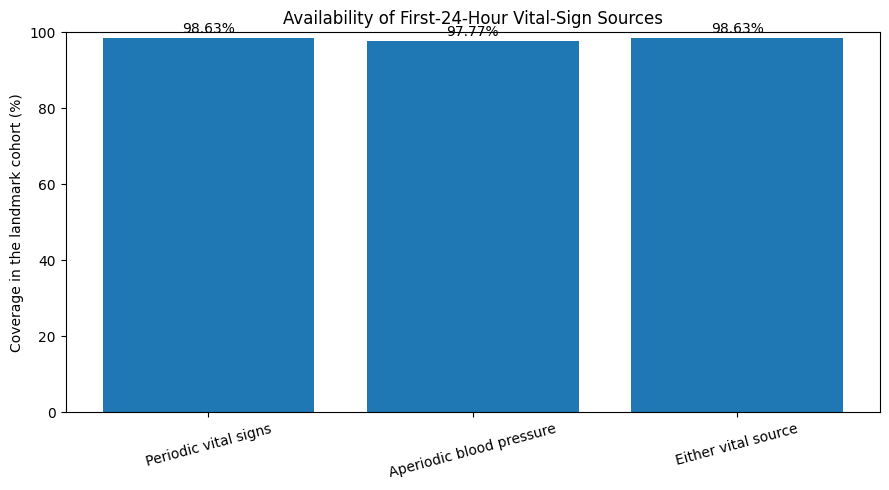

In [125]:
import matplotlib.pyplot as plt


coverage_data = pd.DataFrame(
    {
        "source": [
            "Periodic vital signs",
            "Aperiodic blood pressure",
            "Either vital source",
        ],
        "coverage_percent": [
            100
            * vital_all_features[
                "vital_periodic_any_available"
            ].mean(),

            100
            * vital_all_features[
                "vital_aperiodic_any_available"
            ].mean(),

            100
            * vital_all_features[
                "vital_any_available"
            ].mean(),
        ],
    }
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    coverage_data["source"],
    coverage_data["coverage_percent"],
)

ax.set_ylabel(
    "Coverage in the landmark cohort (%)"
)

ax.set_title(
    "Availability of First-24-Hour Vital-Sign Sources"
)

ax.set_ylim(0, 100)

ax.tick_params(
    axis="x",
    rotation=15,
)

for bar, value in zip(
    bars,
    coverage_data["coverage_percent"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

fig.tight_layout()


VITAL_AVAILABILITY_FIGURE = (
    FIGURE_DIR
    / "vital_first24h_source_coverage.png"
)

fig.savefig(
    VITAL_AVAILABILITY_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Validating the file header for pastHistory

In [126]:
import pandas as pd

from config.paths import FULL_DATA_DIR


PAST_HISTORY_FILE = (
    FULL_DATA_DIR / "pastHistory.csv"
)

PAST_HISTORY_COLUMNS = [
    "patientunitstayid",
    "pasthistoryoffset",
    "pasthistoryenteredoffset",
    "pasthistorynotetype",
    "pasthistorypath",
    "pasthistoryvalue",
    "pasthistoryvaluetext",
]


header = pd.read_csv(
    PAST_HISTORY_FILE,
    nrows=0,
)

missing_columns = set(
    PAST_HISTORY_COLUMNS
).difference(
    header.columns
)

if missing_columns:
    raise KeyError(
        "Missing pastHistory columns: "
        + ", ".join(sorted(missing_columns))
    )

print("pastHistory header validation passed.")
print(f"Source columns: {len(header.columns)}")
print(f"File: {PAST_HISTORY_FILE}")

pastHistory header validation passed.
Source columns: 8
File: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\data\full\pastHistory.csv


#### Loading the landmark cohort IDs

In [127]:
from config.paths import REDUCED_DATA_DIR


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

PAST_HISTORY_LANDMARK_FILE = (
    REDUCED_DATA_DIR
    / "past_history_landmark24h_raw.csv"
)


landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

landmark_ids["patientunitstayid"] = pd.to_numeric(
    landmark_ids["patientunitstayid"],
    errors="raise",
).astype("int64")

landmark_id_set = set(
    landmark_ids["patientunitstayid"]
)

assert len(landmark_id_set) == 1_389
assert landmark_ids["patientunitstayid"].is_unique

#### Extracting landmark-safe records

In [128]:
CHUNK_SIZE = 500_000

if PAST_HISTORY_LANDMARK_FILE.exists():
    PAST_HISTORY_LANDMARK_FILE.unlink()


total_source_rows = 0
cohort_rows_before_cutoff = 0
retained_rows = 0

cohort_stays_with_any_history: set[int] = set()
landmark_stays_with_safe_history: set[int] = set()

first_write = True


reader = pd.read_csv(
    PAST_HISTORY_FILE,
    usecols=PAST_HISTORY_COLUMNS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)


for chunk_number, chunk in enumerate(
    reader,
    start=1,
):
    total_source_rows += len(chunk)

    chunk["patientunitstayid"] = pd.to_numeric(
        chunk["patientunitstayid"],
        errors="coerce",
    )

    chunk["pasthistoryoffset"] = pd.to_numeric(
        chunk["pasthistoryoffset"],
        errors="coerce",
    )

    chunk["pasthistoryenteredoffset"] = pd.to_numeric(
        chunk["pasthistoryenteredoffset"],
        errors="coerce",
    )

    cohort_mask = chunk[
        "patientunitstayid"
    ].isin(landmark_id_set)

    cohort_chunk = chunk.loc[
        cohort_mask
    ].copy()

    cohort_rows_before_cutoff += len(
        cohort_chunk
    )

    cohort_stays_with_any_history.update(
        cohort_chunk[
            "patientunitstayid"
        ]
        .dropna()
        .astype("int64")
        .unique()
        .tolist()
    )

    # Conservative 24-hour information-availability rule
    landmark_safe_mask = (
        cohort_chunk[
            "pasthistoryoffset"
        ].le(1440)
        & cohort_chunk[
            "pasthistoryenteredoffset"
        ].le(1440)
    )

    selected = cohort_chunk.loc[
        landmark_safe_mask,
        PAST_HISTORY_COLUMNS,
    ].copy()

    if selected.empty:
        print(
            f"Chunk {chunk_number}: "
            "no landmark-safe records"
        )
        continue

    selected["patientunitstayid"] = (
        selected["patientunitstayid"]
        .astype("int64")
    )

    landmark_stays_with_safe_history.update(
        selected[
            "patientunitstayid"
        ]
        .unique()
        .tolist()
    )

    selected.to_csv(
        PAST_HISTORY_LANDMARK_FILE,
        mode="w" if first_write else "a",
        header=first_write,
        index=False,
    )

    first_write = False
    retained_rows += len(selected)

    print(
        f"Chunk {chunk_number}: "
        f"{len(selected):,} rows retained"
    )


if first_write:
    raise RuntimeError(
        "No landmark-safe past-history records were found."
    )


late_rows_excluded = (
    cohort_rows_before_cutoff
    - retained_rows
)


print("\nExtraction completed.")

print(
    "Source rows scanned:",
    f"{total_source_rows:,}",
)

print(
    "Landmark-cohort history rows before time filtering:",
    f"{cohort_rows_before_cutoff:,}",
)

print(
    "Landmark-safe history rows retained:",
    f"{retained_rows:,}",
)

print(
    "Late history rows excluded:",
    f"{late_rows_excluded:,}",
)

print(
    "Landmark stays with any history record:",
    f"{len(cohort_stays_with_any_history):,}",
)

print(
    "Landmark stays with history available by 24 hours:",
    f"{len(landmark_stays_with_safe_history):,}",
)

print(
    "Landmark-safe history coverage:",
    (
        f"{100 * len(landmark_stays_with_safe_history) / 1_389:.2f}%"
    ),
)

print(
    f"Private output: {PAST_HISTORY_LANDMARK_FILE}"
)

Chunk 1: 4,207 rows retained
Chunk 2: 3,402 rows retained
Chunk 3: 925 rows retained

Extraction completed.
Source rows scanned: 1,149,180
Landmark-cohort history rows before time filtering: 15,140
Landmark-safe history rows retained: 8,534
Late history rows excluded: 6,606
Landmark stays with any history record: 1,379
Landmark stays with history available by 24 hours: 1,372
Landmark-safe history coverage: 98.78%
Private output: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\past_history_landmark24h_raw.csv


#### Validating the private extraction

In [129]:
past_history = pd.read_csv(
    PAST_HISTORY_LANDMARK_FILE,
    low_memory=False,
)

past_history["patientunitstayid"] = pd.to_numeric(
    past_history["patientunitstayid"],
    errors="raise",
).astype("int64")

past_history["pasthistoryoffset"] = pd.to_numeric(
    past_history["pasthistoryoffset"],
    errors="raise",
)

past_history["pasthistoryenteredoffset"] = pd.to_numeric(
    past_history["pasthistoryenteredoffset"],
    errors="raise",
)


assert set(
    past_history[
        "patientunitstayid"
    ].unique()
).issubset(landmark_id_set)

assert past_history[
    "pasthistoryoffset"
].le(1440).all()

assert past_history[
    "pasthistoryenteredoffset"
].le(1440).all()


print(
    "Rows:",
    f"{len(past_history):,}",
)

print(
    "Unique landmark stays:",
    f"{past_history['patientunitstayid'].nunique():,}",
)

print(
    "Unique history paths:",
    f"{past_history['pasthistorypath'].nunique():,}",
)

print(
    "Minimum history offset:",
    past_history[
        "pasthistoryoffset"
    ].min(),
)

print(
    "Maximum history offset:",
    past_history[
        "pasthistoryoffset"
    ].max(),
)

print(
    "Minimum entry offset:",
    past_history[
        "pasthistoryenteredoffset"
    ].min(),
)

print(
    "Maximum entry offset:",
    past_history[
        "pasthistoryenteredoffset"
    ].max(),
)

Rows: 8,534
Unique landmark stays: 1,372
Unique history paths: 199
Minimum history offset: -42622
Maximum history offset: 1436
Minimum entry offset: -442
Maximum entry offset: 1438


#### Normalizing paths and values

In [130]:
def normalize_text(
    series: pd.Series,
) -> pd.Series:
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
    )


past_history["history_path_clean"] = (
    normalize_text(
        past_history[
            "pasthistorypath"
        ]
    )
)

past_history["history_value_clean"] = (
    normalize_text(
        past_history[
            "pasthistoryvalue"
        ]
    )
)

past_history[
    "history_value_text_clean"
] = normalize_text(
    past_history[
        "pasthistoryvaluetext"
    ]
)

#### Creating the path-level catalogue

In [131]:
from config.paths import COHORT_DIR


QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


past_history_path_summary = (
    past_history
    .groupby(
        [
            "pasthistorypath",
        ],
        dropna=False,
    )
    .agg(
        record_count=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays=(
            "patientunitstayid",
            "nunique",
        ),
        unique_values=(
            "pasthistoryvalue",
            "nunique",
        ),
    )
    .reset_index()
)


past_history_path_summary[
    "coverage_percent"
] = (
    100
    * past_history_path_summary[
        "unique_icu_stays"
    ]
    / len(landmark_ids)
)


past_history_path_summary = (
    past_history_path_summary
    .sort_values(
        [
            "unique_icu_stays",
            "record_count",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


PAST_HISTORY_PATH_SUMMARY_FILE = (
    QC_DIR
    / "past_history_path_summary.csv"
)

past_history_path_summary.to_csv(
    PAST_HISTORY_PATH_SUMMARY_FILE,
    index=False,
)

print(
    f"Path summary: {PAST_HISTORY_PATH_SUMMARY_FILE}"
)

Path summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\past_history_path_summary.csv


#### Creating the path–value catalogue

In [132]:
past_history_path_value_summary = (
    past_history
    .groupby(
        [
            "pasthistorypath",
            "pasthistoryvalue",
        ],
        dropna=False,
    )
    .agg(
        record_count=(
            "patientunitstayid",
            "size",
        ),
        unique_icu_stays=(
            "patientunitstayid",
            "nunique",
        ),
    )
    .reset_index()
)


past_history_path_value_summary[
    "coverage_percent"
] = (
    100
    * past_history_path_value_summary[
        "unique_icu_stays"
    ]
    / len(landmark_ids)
)


past_history_path_value_summary = (
    past_history_path_value_summary
    .sort_values(
        [
            "pasthistorypath",
            "unique_icu_stays",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


PAST_HISTORY_PATH_VALUE_FILE = (
    QC_DIR
    / "past_history_path_value_summary.csv"
)

past_history_path_value_summary.to_csv(
    PAST_HISTORY_PATH_VALUE_FILE,
    index=False,
)

print(
    "Path–value summary:",
    PAST_HISTORY_PATH_VALUE_FILE,
)

Path–value summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\past_history_path_value_summary.csv


#### Creating a focused comorbidity catalogue

In [133]:
COMORBIDITY_PATTERN = (
    r"copd|emphysema|chronic bronchitis|"
    r"asthma|pulmonary hypertension|"
    r"home oxygen|respiratory failure|"
    r"heart failure|congestive|chf|"
    r"coronary|ischemic heart|myocardial|"
    r"hypertension|arrhythm|atrial fibrillation|"
    r"valvular|peripheral vascular|"
    r"stroke|cerebrovascular|tia|"
    r"dementia|alzheimer|"
    r"diabetes|"
    r"renal|kidney|dialysis|"
    r"liver|hepatic|cirrhosis|"
    r"cancer|malign|metast|lymphoma|leukemia|"
    r"immunosupp|transplant|hiv|aids|"
    r"smok|tobacco|alcohol|drug"
)


candidate_history_summary = (
    past_history_path_value_summary.loc[
        past_history_path_value_summary[
            "pasthistorypath"
        ]
        .fillna("")
        .astype(str)
        .str.contains(
            COMORBIDITY_PATTERN,
            case=False,
            regex=True,
        )
    ]
    .copy()
)


CANDIDATE_HISTORY_FILE = (
    QC_DIR
    / "past_history_candidate_comorbidity_summary.csv"
)

candidate_history_summary.to_csv(
    CANDIDATE_HISTORY_FILE,
    index=False,
)


print(
    "Candidate path–value combinations:",
    f"{len(candidate_history_summary):,}",
)

print(
    f"Candidate catalogue: {CANDIDATE_HISTORY_FILE}"
)

display(candidate_history_summary)

Candidate path–value combinations: 126
Candidate catalogue: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\past_history_candidate_comorbidity_summary.csv


,pasthistorypath,pasthistoryvalue,record_count,unique_icu_stays,coverage_percent
3,notes/Progress Notes/Past History/Organ System...,MAT,2,1,0.071994
4,notes/Progress Notes/Past History/Organ System...,SVT- other,11,9,0.647948
5,notes/Progress Notes/Past History/Organ System...,atrial fibrillation - chronic,134,98,7.055436
6,notes/Progress Notes/Past History/Organ System...,atrial fibrillation - intermittent,47,33,2.375810
7,notes/Progress Notes/Past History/Organ System...,sick sinus syndrome,2,2,0.143988
...,...,...,...,...,...
186,notes/Progress Notes/Past History/Organ System...,renal insufficiency - baseline creatinine unknown,24,23,1.655868
187,notes/Progress Notes/Past History/Organ System...,renal insufficiency - creatinine 1-2,35,24,1.727862
188,notes/Progress Notes/Past History/Organ System...,renal insufficiency - creatinine 2-3,12,11,0.791937
189,notes/Progress Notes/Past History/Organ System...,renal insufficiency - creatinine 3-4,3,2,0.143988


#### Loading and normalizing the private history data

In [134]:
from __future__ import annotations

import re

import numpy as np
import pandas as pd

from config.paths import (
    COHORT_DIR,
    REDUCED_DATA_DIR,
)


LANDMARK_IDS_FILE = (
    REDUCED_DATA_DIR
    / "lung_cancer_landmark24h_ids.csv"
)

PAST_HISTORY_RAW_FILE = (
    REDUCED_DATA_DIR
    / "past_history_landmark24h_raw.csv"
)

PAST_HISTORY_FEATURES_CSV = (
    REDUCED_DATA_DIR
    / "past_history_features_v001.csv"
)

PAST_HISTORY_FEATURES_PARQUET = (
    REDUCED_DATA_DIR
    / "past_history_features_v001.parquet"
)

QC_DIR = COHORT_DIR / "qc"

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [135]:
landmark_ids = pd.read_csv(
    LANDMARK_IDS_FILE,
    usecols=["patientunitstayid"],
)

past_history = pd.read_csv(
    PAST_HISTORY_RAW_FILE,
    low_memory=False,
)


for dataframe in (
    landmark_ids,
    past_history,
):
    dataframe["patientunitstayid"] = pd.to_numeric(
        dataframe["patientunitstayid"],
        errors="raise",
    ).astype("int64")


assert len(landmark_ids) == 1_389
assert landmark_ids["patientunitstayid"].is_unique

assert set(
    past_history["patientunitstayid"].unique()
).issubset(
    set(landmark_ids["patientunitstayid"])
)

#### Normalizing the structured path

In [136]:
def normalize_history_text(
    series: pd.Series,
) -> pd.Series:
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
    )


past_history["history_path_clean"] = (
    normalize_history_text(
        past_history["pasthistorypath"]
    )
)

past_history["history_value_clean"] = (
    normalize_history_text(
        past_history["pasthistoryvalue"]
    )
)

#### Building documentation-status variables

In [137]:
path = past_history["history_path_clean"]


past_history["status_performed"] = (
    path.str.contains(
        (
            r"/past history obtain options/"
            r"performed$"
        ),
        regex=True,
    )
    & ~path.str.contains(
        r"/not performed$",
        regex=True,
    )
).astype("int8")


past_history["status_no_health_problems"] = (
    path.str.contains(
        (
            r"/past history obtain options/"
            r"no health problems$"
        ),
        regex=True,
    )
).astype("int8")


past_history["status_not_obtainable"] = (
    path.str.contains(
        (
            r"/past history obtain options/"
            r"not obtainable$"
        ),
        regex=True,
    )
).astype("int8")


past_history["status_not_performed"] = (
    path.str.contains(
        (
            r"/past history obtain options/"
            r"not performed$"
        ),
        regex=True,
    )
).astype("int8")


past_history["is_status_record"] = (
    path.str.contains(
        r"/past history obtain options/",
        regex=True,
    )
).astype("int8")


past_history["is_clinical_history_record"] = (
    (
        past_history["history_path_clean"].ne("")
        & past_history["is_status_record"].eq(0)
    )
).astype("int8")

#### Summarizing status by ICU stay

In [138]:
history_status = (
    past_history
    .groupby(
        "patientunitstayid",
        as_index=False,
    )
    .agg(
        history_record_count=(
            "history_path_clean",
            "size",
        ),
        history_clinical_record_count=(
            "is_clinical_history_record",
            "sum",
        ),
        history_status_performed=(
            "status_performed",
            "max",
        ),
        history_status_no_health_problems=(
            "status_no_health_problems",
            "max",
        ),
        history_status_not_obtainable=(
            "status_not_obtainable",
            "max",
        ),
        history_status_not_performed=(
            "status_not_performed",
            "max",
        ),
    )
)

#### Restoring all 1,389 patients

In [139]:
history_base = landmark_ids.merge(
    history_status,
    on="patientunitstayid",
    how="left",
    validate="one_to_one",
)


status_columns = [
    "history_record_count",
    "history_clinical_record_count",
    "history_status_performed",
    "history_status_no_health_problems",
    "history_status_not_obtainable",
    "history_status_not_performed",
]


history_base[status_columns] = (
    history_base[status_columns]
    .fillna(0)
    .astype("int64")
)


history_base["history_any_record_available"] = (
    history_base["history_record_count"]
    .gt(0)
    .astype("int8")
)

#### Defining whether the structured history is clinically assessable

In [140]:
history_base["history_assessable_by_24h"] = (
    (
        history_base[
            "history_clinical_record_count"
        ].gt(0)

        | history_base[
            "history_status_performed"
        ].eq(1)

        | history_base[
            "history_status_no_health_problems"
        ].eq(1)
    )
    .astype("int8")
)


history_base["history_explicitly_unavailable"] = (
    (
        (
            history_base[
                "history_status_not_obtainable"
            ].eq(1)

            | history_base[
                "history_status_not_performed"
            ].eq(1)
        )

        & history_base[
            "history_assessable_by_24h"
        ].eq(0)
    )
    .astype("int8")
)

#### Defining clinically grouped history features

In [141]:
HISTORY_FEATURE_DEFINITIONS = {
    # Pulmonary history
    "history_copd": {
        "pattern": r"/pulmonary/copd/",
        "group": "pulmonary",
        "primary_candidate": True,
        "description": "Any documented COPD category",
    },
    "history_copd_severe": {
        "pattern": (
            r"/pulmonary/copd/"
            r"copd\s*-\s*severe$"
        ),
        "group": "pulmonary",
        "primary_candidate": False,
        "description": "Severe COPD category",
    },
    "history_asthma": {
        "pattern": r"/pulmonary/asthma/",
        "group": "pulmonary",
        "primary_candidate": True,
        "description": "Documented asthma",
    },
    "history_home_oxygen": {
        "pattern": r"/pulmonary/home oxygen/",
        "group": "pulmonary",
        "primary_candidate": True,
        "description": "Home oxygen use",
    },
    "history_prior_respiratory_failure": {
        "pattern": (
            r"/pulmonary/"
            r"respiratory failure/"
        ),
        "group": "pulmonary",
        "primary_candidate": False,
        "description": "Prior respiratory failure",
    },
    "history_restrictive_lung_disease": {
        "pattern": (
            r"/pulmonary/"
            r"restrictive disease/"
        ),
        "group": "pulmonary",
        "primary_candidate": False,
        "description": "Restrictive pulmonary disease",
    },

    # Cardiovascular history
    "history_heart_failure": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"congestive heart failure/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": "Congestive heart failure",
    },
    "history_coronary_artery_disease": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"(?:angina|myocardial infarction|"
            r"coronary artery bypass|"
            r"procedural coronary intervention)/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": (
            "Angina, myocardial infarction, "
            "CABG or coronary intervention"
        ),
    },
    "history_arrhythmia": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"arrhythmias/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": "Any structured arrhythmia history",
    },
    "history_atrial_fibrillation": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"arrhythmias/"
            r"atrial fibrillation"
        ),
        "group": "cardiovascular",
        "primary_candidate": False,
        "description": "Chronic or intermittent atrial fibrillation",
    },
    "history_hypertension": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"hypertension requiring treatment/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": "Hypertension requiring treatment",
    },
    "history_peripheral_vascular_disease": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"peripheral vascular disease/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": "Peripheral vascular disease",
    },
    "history_venous_thromboembolism": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"(?:pulmonary embolism|"
            r"venous thrombosis)/"
        ),
        "group": "cardiovascular",
        "primary_candidate": True,
        "description": "Prior pulmonary embolism or DVT",
    },
    "history_valvular_disease": {
        "pattern": (
            r"/cardiovascular \(r\)/"
            r"valve disease/"
        ),
        "group": "cardiovascular",
        "primary_candidate": False,
        "description": "Valvular disease or valve replacement",
    },

    # Metabolic, renal and hepatic history
    "history_diabetes": {
        "pattern": (
            r"/endocrine \(r\)/"
            r"(?:insulin dependent diabetes|"
            r"non-insulin dependent diabetes)/"
        ),
        "group": "metabolic",
        "primary_candidate": True,
        "description": "Any documented diabetes category",
    },
    "history_chronic_kidney_disease": {
        "pattern": (
            r"/renal \(r\)/"
            r"(?:renal failure|renal insufficiency)/"
        ),
        "group": "renal",
        "primary_candidate": True,
        "description": "Renal failure or renal insufficiency",
    },
    "history_dialysis": {
        "pattern": (
            r"/renal \(r\)/renal failure/"
            r"renal failure - "
            r"(?:hemodialysis|peritoneal dialysis)$"
        ),
        "group": "renal",
        "primary_candidate": False,
        "description": "Prior hemodialysis or peritoneal dialysis",
    },
    "history_cirrhosis": {
        "pattern": (
            r"/gastrointestinal \(r\)/"
            r"cirrhosis/"
        ),
        "group": "hepatic",
        "primary_candidate": False,
        "description": "Structured cirrhosis history",
    },

    # Neurologic history
    "history_stroke_or_tia": {
        "pattern": (
            r"/neurologic/"
            r"(?:strokes|tia\(s\))/"
        ),
        "group": "neurologic",
        "primary_candidate": True,
        "description": "Prior stroke or transient ischemic attack",
    },
    "history_dementia": {
        "pattern": r"/neurologic/dementia/",
        "group": "neurologic",
        "primary_candidate": False,
        "description": "Documented dementia",
    },
    "history_seizure_disorder": {
        "pattern": r"/neurologic/seizures/",
        "group": "neurologic",
        "primary_candidate": False,
        "description": "Any structured seizure history",
    },

    # Cancer and immune history
    "history_metastatic_disease": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer/metastases/"
        ),
        "group": "oncology",
        "primary_candidate": True,
        "description": "Metastatic cancer at any documented site",
    },
    "history_brain_metastasis": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer/metastases/brain$"
        ),
        "group": "oncology",
        "primary_candidate": False,
        "description": "Documented brain metastasis",
    },
    "history_bone_metastasis": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer/metastases/bone$"
        ),
        "group": "oncology",
        "primary_candidate": False,
        "description": "Documented bone metastasis",
    },
    "history_recent_chemotherapy_or_bmt": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer therapy/chemotherapy/"
            r"(?:chemotherapy within past|"
            r"bmt within past 12 mos\.)"
        ),
        "group": "oncology",
        "primary_candidate": True,
        "description": (
            "Recent chemotherapy or bone-marrow "
            "transplantation"
        ),
    },
    "history_recent_radiotherapy": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer therapy/"
            r"radiation therapy within past 6 months/"
        ),
        "group": "oncology",
        "primary_candidate": True,
        "description": "Radiotherapy within the previous six months",
    },
    "history_other_primary_malignancy": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer/cancer-primary site/"
            r"(?!lung$)[^/]+$"
        ),
        "group": "oncology",
        "primary_candidate": False,
        "description": "Documented primary malignancy other than lung",
    },
    "history_hematologic_malignancy": {
        "pattern": (
            r"/hematology/oncology \(r\)/"
            r"cancer/hematologic malignancy/"
        ),
        "group": "oncology",
        "primary_candidate": False,
        "description": "Leukemia, lymphoma, myeloma or related disease",
    },
    "history_immunosuppression": {
        "pattern": (
            r"/infectious disease \(r\)/"
            r"immunosuppression within past 6 months/"
        ),
        "group": "immune",
        "primary_candidate": False,
        "description": "Recent structured immunosuppression history",
    },
    "history_hiv_or_aids": {
        "pattern": (
            r"/infectious disease \(r\)/"
            r"(?:hiv \(only\)|aids)/"
        ),
        "group": "immune",
        "primary_candidate": False,
        "description": "HIV-positive status or AIDS",
    },
}

#### Creating the patient-level binary features

In [142]:
history_features = history_base.copy()

assessable_mask = (
    history_features[
        "history_assessable_by_24h"
    ].eq(1)
)


for (
    feature_name,
    definition,
) in HISTORY_FEATURE_DEFINITIONS.items():

    feature_pattern = definition["pattern"]

    matched_ids = set(
        past_history.loc[
            past_history[
                "history_path_clean"
            ].str.contains(
                feature_pattern,
                regex=True,
                na=False,
            ),
            "patientunitstayid",
        ]
        .unique()
        .tolist()
    )

    history_features[feature_name] = np.nan

    history_features.loc[
        assessable_mask,
        feature_name,
    ] = 0.0

    history_features.loc[
        history_features[
            "patientunitstayid"
        ].isin(matched_ids),
        feature_name,
    ] = 1.0

#### Validating hierarchical relationships

In [143]:
assert (
    history_features[
        "history_copd_severe"
    ].fillna(0)
    <= history_features[
        "history_copd"
    ].fillna(0)
).all()


assert (
    history_features[
        "history_atrial_fibrillation"
    ].fillna(0)
    <= history_features[
        "history_arrhythmia"
    ].fillna(0)
).all()


assert (
    history_features[
        "history_dialysis"
    ].fillna(0)
    <= history_features[
        "history_chronic_kidney_disease"
    ].fillna(0)
).all()


assert (
    history_features[
        "history_brain_metastasis"
    ].fillna(0)
    <= history_features[
        "history_metastatic_disease"
    ].fillna(0)
).all()


assert (
    history_features[
        "history_bone_metastasis"
    ].fillna(0)
    <= history_features[
        "history_metastatic_disease"
    ].fillna(0)
).all()

#### Exporting the private feature block

In [144]:
condition_feature_columns = list(
    HISTORY_FEATURE_DEFINITIONS
)


assert len(history_features) == 1_389

assert history_features[
    "patientunitstayid"
].is_unique


history_features.to_csv(
    PAST_HISTORY_FEATURES_CSV,
    index=False,
)

history_features.to_parquet(
    PAST_HISTORY_FEATURES_PARQUET,
    index=False,
    engine="pyarrow",
)


print(
    f"Private CSV: {PAST_HISTORY_FEATURES_CSV}"
)

print(
    f"Private Parquet: {PAST_HISTORY_FEATURES_PARQUET}"
)

Private CSV: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\past_history_features_v001.csv
Private Parquet: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\private_data\reduced\past_history_features_v001.parquet


#### Creating a privacy-safe prevalence summary

In [145]:
prevalence_rows = []


for feature in condition_feature_columns:
    valid_values = history_features[
        feature
    ].dropna()

    positive_n = int(
        valid_values.eq(1).sum()
    )

    negative_n = int(
        valid_values.eq(0).sum()
    )

    missing_n = int(
        history_features[
            feature
        ].isna().sum()
    )

    assessable_n = (
        positive_n + negative_n
    )

    prevalence_rows.append(
        {
            "feature": feature,
            "positive_n": positive_n,
            "negative_n": negative_n,
            "missing_n": missing_n,
            "assessable_n": assessable_n,
            "prevalence_percent_assessable": (
                100
                * positive_n
                / assessable_n
                if assessable_n > 0
                else np.nan
            ),
            "rare_positive_count_under_20": (
                positive_n < 20
            ),
        }
    )


history_prevalence_summary = (
    pd.DataFrame(
        prevalence_rows
    )
    .sort_values(
        "positive_n",
        ascending=False,
    )
    .reset_index(drop=True)
)

#### Saving it

In [146]:
HISTORY_PREVALENCE_FILE = (
    QC_DIR
    / "past_history_feature_prevalence_summary.csv"
)

history_prevalence_summary.to_csv(
    HISTORY_PREVALENCE_FILE,
    index=False,
)

display(history_prevalence_summary)

print(
    f"Prevalence summary: {HISTORY_PREVALENCE_FILE}"
)

,feature,positive_n,negative_n,missing_n,assessable_n,prevalence_percent_assessable,rare_positive_count_under_20
0,history_hypertension,714,646,29,1360,52.500000,False
1,history_copd,487,873,29,1360,35.808824,False
2,history_metastatic_disease,323,1037,29,1360,23.750000,False
3,history_diabetes,274,1086,29,1360,20.147059,False
4,history_recent_chemotherapy_or_bmt,228,1132,29,1360,16.764706,False
5,history_coronary_artery_disease,201,1159,29,1360,14.779412,False
6,history_recent_radiotherapy,147,1213,29,1360,10.808824,False
7,history_arrhythmia,147,1213,29,1360,10.808824,False
8,history_copd_severe,136,1224,29,1360,10.000000,False
9,history_heart_failure,135,1225,29,1360,9.926471,False


Prevalence summary: D:\Spain\Online Courses\10. Data Analysis Specialization\3. Python\Sprint 13\Assignment\eicu-lung-cancer-los\outputs\cohort\qc\past_history_feature_prevalence_summary.csv


#### Creating the feature manifest

In [147]:
history_feature_manifest = pd.DataFrame(
    [
        {
            "feature": feature,
            "feature_group": definition[
                "group"
            ],
            "description": definition[
                "description"
            ],
            "primary_model_candidate": definition[
                "primary_candidate"
            ],
            "source_table": "pastHistory",
            "observation_window": (
                "Available by 24-hour landmark"
            ),
        }
        for (
            feature,
            definition,
        ) in HISTORY_FEATURE_DEFINITIONS.items()
    ]
)


HISTORY_MANIFEST_FILE = (
    QC_DIR
    / "past_history_feature_manifest.csv"
)

history_feature_manifest.to_csv(
    HISTORY_MANIFEST_FILE,
    index=False,
)

#### Printing the final block summary

In [148]:
assessable_n = int(
    history_features[
        "history_assessable_by_24h"
    ].sum()
)

not_assessable_n = (
    len(history_features)
    - assessable_n
)


print(
    "Rows in past-history feature block:",
    f"{len(history_features):,}",
)

print(
    "Number of condition features:",
    f"{len(condition_feature_columns):,}",
)

print(
    "Patients with assessable history:",
    f"{assessable_n:,}",
)

print(
    "Patients without assessable history:",
    f"{not_assessable_n:,}",
)

print(
    "Assessable-history coverage:",
    (
        f"{100 * assessable_n / len(history_features):.2f}%"
    ),
)

print(
    "Patients with any history record:",
    f"{history_features['history_any_record_available'].sum():,}",
)

print(
    "Patients with no history record:",
    (
        len(history_features)
        - history_features[
            "history_any_record_available"
        ].sum()
    ),
)

Rows in past-history feature block: 1,389
Number of condition features: 30
Patients with assessable history: 1,360
Patients without assessable history: 29
Assessable-history coverage: 97.91%
Patients with any history record: 1,372
Patients with no history record: 17
